# SHAP Explainability and External Validation — Final Optimized Models

## Introduction
This notebook is doing four related jobs. First, it is teaching SHAP clearly enough that a reader can understand what SHAP is, why it is used, and what kind of answers it gives. Second, it is explaining the final optimized non-invasive model. Third, it is explaining the final optimized invasive model. Fourth, it is testing the final non-invasive model on the survey external validation set.

Explainability is not optional for a clinical AI tool. A model that predicts risk without showing why it reached that result is hard to trust in practice. SHAP is giving feature-level explanations so clinicians can see which features are pushing a prediction upward or downward.

The Model 1 SHAP section is revealing what the final non-invasive model is doing with routine screening features such as BMI, symptom burden, cycle features, blood pressure, and lifestyle signals. This is the most clinically deployable part of the study because these are the features that can be collected most easily in real screening work.

The Model 2 SHAP section is revealing what the final invasive benchmark model is doing with hormonal and ultrasound features. This section is helping us check whether the model is learning the same biomarker patterns that the literature already describes in PCOS.

The two SHAP sections are being treated as separate analyses. The models use different feature sets, so comparing the SHAP value of a non-invasive feature against the SHAP value of an invasive biomarker would not be a meaningful clinical comparison.

The survey validation section is testing whether the final Model 1 pipeline can still produce useful results outside the clinical training setting. Because some survey features were placeholder-filled in Notebook 07, this is an external-style check rather than a perfect external clinical validation.

## Output Files
| Path | Meaning |
| --- | --- |
| `images/shap/01_shap_concept_diagram.png` | Main visual that introduces local and global SHAP ideas. |
| `images/shap/02_shap_game_theory_illustration.png` | Game-theory visual showing how coalitions build the prediction credit idea. |
| `images/shap/model1/03-13_*.png` | Model 1 SHAP figures: global, local, dependence, interaction, and meta-learner weight views. |
| `images/shap/model2/14-24_*.png` | Model 2 SHAP figures: global, local, dependence, interaction, and meta-learner weight views. |
| `images/shap/survey/25-29_*.png` | Survey validation figures: class balance, ROC, confusion matrix, and survey SHAP views. |
| `cleaned_data/modelling_sets/shap_values_model1.npy` | Saved Model 1 RF-based SHAP matrix on the clinical test set. |
| `cleaned_data/modelling_sets/shap_values_model2.npy` | Saved Model 2 RF-based SHAP matrix on the clinical test set. |
| `cleaned_data/modelling_sets/shap_values_survey.npy` | Saved survey SHAP matrix using the Model 1 RF explainer. |
| `cleaned_data/modelling_sets/shap_feature_ranking_model1.csv` | Saved Model 1 global SHAP ranking table. |
| `cleaned_data/modelling_sets/shap_feature_ranking_model2.csv` | Saved Model 2 global SHAP ranking table. |
| `cleaned_data/modelling_sets/survey_validation_results.csv` | Saved external-style survey validation metrics. |
| `cleaned_data/modelling_sets/survey_validation_predictions.csv` | Saved row-level survey predictions and probabilities. |


## Section 1 — Imports and Configuration


In [131]:
# Importing the packages for SHAP, plotting, saved model loading, and validation is preparing the notebook for explainability work.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
import json
import joblib
from pathlib import Path
from IPython.display import display, Markdown

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "SHAP is required for Notebook 11. Install it with `%pip install shap` "
        "or `conda install -c conda-forge shap`, then restart the kernel."
    ) from exc

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, RocCurveDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
shap.initjs()

RANDOM_STATE = 42
TARGET = 'pcos_y_n'

COLORS = {
    'pcos_pos': '#E63946',
    'pcos_neg': '#457B9D',
    'model1': '#2A9D8F',
    'model2': '#E9C46A',
    'shap_pos': '#E63946',
    'shap_neg': '#457B9D',
    'neutral': '#2C3E50',
    'survey': '#9B2226',
}


In [132]:
# Resolving the project root is making the notebook work from either the repo root or the notebooks folder.
search_start = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [search_start, *search_start.parents]:
    if (
        (candidate / 'cleaned_data').exists() and
        (candidate / 'models').exists() and
        (candidate / 'notebooks').exists() and
        (candidate / 'README.md').exists()
    ):
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not resolve the project root.')
os.chdir(PROJECT_ROOT)
print(f'Project root resolved to: {PROJECT_ROOT}')

# Creating the SHAP output folders is making sure all saved figures have fixed locations.
os.makedirs(PROJECT_ROOT / 'images' / 'shap' / 'model1', exist_ok=True)
os.makedirs(PROJECT_ROOT / 'images' / 'shap' / 'model2', exist_ok=True)
os.makedirs(PROJECT_ROOT / 'images' / 'shap' / 'survey', exist_ok=True)
print('Directory ready: images/shap/model1')
print('Directory ready: images/shap/model2')
print('Directory ready: images/shap/survey')


Project root resolved to: C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic
Directory ready: images/shap/model1
Directory ready: images/shap/model2
Directory ready: images/shap/survey


In [133]:
# Loading the locked modelling data and saved final model artifacts is grounding the notebook in the current repo state.
train1 = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'model1_train.csv')
test1 = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'model1_test.csv')
train2 = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'model2_train.csv')
test2 = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'model2_test.csv')
survey = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'survey_external_validation.csv')

with open(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'feature_names_model1.json', encoding='utf-8') as f:
    MODEL1_FEATURES = json.load(f)
with open(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'feature_names_model2.json', encoding='utf-8') as f:
    MODEL2_FEATURES = json.load(f)

with open(PROJECT_ROOT / 'models' / 'model1_best_params.json', encoding='utf-8') as f:
    m1_best = json.load(f)
with open(PROJECT_ROOT / 'models' / 'model2_best_params.json', encoding='utf-8') as f:
    m2_best = json.load(f)

final_bundle_m1 = joblib.load(PROJECT_ROOT / 'models' / 'model1_final_optimized.pkl')
final_bundle_m2 = joblib.load(PROJECT_ROOT / 'models' / 'model2_final_optimized.pkl')
final_results = pd.read_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'final_model_results.csv')

print('Loaded data shapes:')
print(f'train1: {train1.shape}')
print(f'test1 : {test1.shape}')
print(f'train2: {train2.shape}')
print(f'test2 : {test2.shape}')
print(f'survey: {survey.shape}')
print()
print('Model 1 best params JSON:')
print(json.dumps(m1_best, indent=2))
print()
print('Model 2 best params JSON:')
print(json.dumps(m2_best, indent=2))
print()
print('Final results table:')
print(final_results.to_string(index=False))


Loaded data shapes:
train1: (582, 20)
test1 : (109, 20)
train2: (582, 16)
test2 : (109, 16)
survey: (464, 20)

Model 1 best params JSON:
{
  "optimizer": "CSO",
  "stack_family": "lr",
  "auc": 0.95475221185433,
  "params": {
    "rf_n_estimators": 479.0,
    "rf_max_depth": 20.0,
    "rf_min_samples_split": 2.0,
    "xgb_n_estimators": 400.0,
    "xgb_learning_rate": 0.01,
    "xgb_max_depth": 2.0,
    "xgb_subsample": 1.0,
    "meta_C": 10.0,
    "meta_n_estimators": 300.0
  }
}

Model 2 best params JSON:
{
  "optimizer": "RSO",
  "stack_family": "lr",
  "auc": 0.9421441383341058,
  "params": {
    "rf_n_estimators": 282.0,
    "rf_max_depth": 12.0,
    "rf_min_samples_split": 4.0,
    "xgb_n_estimators": 400.0,
    "xgb_learning_rate": 0.07506141677114628,
    "xgb_max_depth": 3.0,
    "xgb_subsample": 0.9904882049756158,
    "meta_C": 9.221409913649332,
    "meta_n_estimators": 192.0
  }
}

Final results table:
                  model  accuracy  precision  recall     f1    auc mode

In [134]:
# Separating features and targets is preparing the train, test, and survey arrays used in the explainability and validation sections.
X1_train = train1[MODEL1_FEATURES].values
y1_train = train1[TARGET].values
X1_test = test1[MODEL1_FEATURES].values
y1_test = test1[TARGET].values

X2_train = train2[MODEL2_FEATURES].values
y2_train = train2[TARGET].values
X2_test = test2[MODEL2_FEATURES].values
y2_test = test2[TARGET].values

X_survey = survey[MODEL1_FEATURES].values
y_survey = survey[TARGET].values

print(f'X1_train shape: {X1_train.shape}')
print(f'X1_test shape : {X1_test.shape}')
print(f'X2_train shape: {X2_train.shape}')
print(f'X2_test shape : {X2_test.shape}')
print(f'X_survey shape: {X_survey.shape}')
print()
print('Model 1 feature count:', len(MODEL1_FEATURES))
print('Model 2 feature count:', len(MODEL2_FEATURES))


X1_train shape: (582, 19)
X1_test shape : (109, 19)
X2_train shape: (582, 15)
X2_test shape : (109, 15)
X_survey shape: (464, 19)

Model 1 feature count: 19
Model 2 feature count: 15


In [135]:
# Defining shared helper functions is keeping the SHAP and validation sections readable and consistent.
def render_markdown(text: str) -> None:
    display(Markdown(text))


def evaluate_prediction(name: str, y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> dict:
    return {
        'model': name,
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'auc': float(roc_auc_score(y_true, y_proba)),
    }


def stack_predict_proba(bundle: dict, X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    base_order = bundle.get('meta_feature_order', ['LR_prob', 'RF_prob', 'XGB_prob'])
    key_map = {'LR_prob': 'lr', 'RF_prob': 'rf', 'XGB_prob': 'xgb'}
    meta_features = np.column_stack([
        bundle['base_models'][key_map[col]].predict_proba(X)[:, 1]
        for col in base_order
    ])
    proba = bundle['meta_model'].predict_proba(meta_features)[:, 1]
    return meta_features, proba


def extract_positive_shap(shap_values):
    if isinstance(shap_values, list):
        return np.asarray(shap_values[1])
    arr = np.asarray(shap_values)
    if arr.ndim == 3 and arr.shape[-1] == 2:
        return arr[:, :, 1]
    return arr


def extract_positive_expected_value(expected_value):
    if isinstance(expected_value, list):
        return float(expected_value[1])
    arr = np.asarray(expected_value)
    if arr.ndim == 0:
        return float(arr)
    if arr.size == 2:
        return float(arr.reshape(-1)[1])
    return float(arr.reshape(-1)[0])


def select_case_indices(y_true: np.ndarray, y_pred: np.ndarray, y_proba: np.ndarray) -> dict:
    tp = np.where((y_true == 1) & (y_pred == 1))[0]
    fn = np.where((y_true == 1) & (y_pred == 0))[0]
    fp = np.where((y_true == 0) & (y_pred == 1))[0]
    positives = np.where(y_true == 1)[0]
    negatives = np.where(y_true == 0)[0]
    tp_idx = int(tp[np.argmax(y_proba[tp])]) if len(tp) else int(positives[np.argmax(y_proba[positives])])
    fn_idx = int(fn[np.argmin(y_proba[fn])]) if len(fn) else int(positives[np.argmin(y_proba[positives])])
    fp_idx = int(fp[np.argmax(y_proba[fp])]) if len(fp) else int(negatives[np.argmax(y_proba[negatives])])
    return {
        'tp_idx': tp_idx,
        'fn_idx': fn_idx,
        'fp_idx': fp_idx,
        'tp_count': int(len(tp)),
        'fn_count': int(len(fn)),
        'fp_count': int(len(fp)),
    }


def top_signed_contributors(shap_row: np.ndarray, feature_names: list[str], value_row: pd.Series, positive: bool = True, top_n: int = 5) -> list[dict]:
    frame = pd.DataFrame({
        'feature': feature_names,
        'shap_value': shap_row,
        'feature_value': [value_row[name] for name in feature_names],
    })
    frame = frame.sort_values('shap_value', ascending=not positive)
    if positive:
        frame = frame[frame['shap_value'] > 0]
    else:
        frame = frame[frame['shap_value'] < 0]
    return frame.head(top_n).to_dict('records')


def describe_dependence_shape(feature_values: np.ndarray, shap_values: np.ndarray) -> tuple[str, float]:
    if np.std(feature_values) == 0 or np.std(shap_values) == 0:
        return 'flat or unstable', 0.0
    rho = float(np.corrcoef(feature_values, shap_values)[0, 1])
    if np.isnan(rho):
        return 'mixed or irregular', 0.0
    abs_rho = abs(rho)
    if abs_rho >= 0.75:
        return 'strongly monotonic', rho
    if abs_rho >= 0.35:
        return 'moderately monotonic', rho
    return 'non-linear or mixed', rho


def stratified_take(y: np.ndarray, total: int, seed: int = 42):
    rng = np.random.default_rng(seed)
    y = np.asarray(y)
    indices = []
    for cls in sorted(np.unique(y)):
        cls_idx = np.where(y == cls)[0]
        n_take = max(1, int(round(total * (len(cls_idx) / len(y)))))
        n_take = min(n_take, len(cls_idx))
        picked = rng.choice(cls_idx, size=n_take, replace=False)
        indices.extend(picked.tolist())
    indices = sorted(set(indices))
    if len(indices) > total:
        indices = list(rng.choice(indices, size=total, replace=False))
    while len(indices) < total:
        remaining = [idx for idx in range(len(y)) if idx not in indices]
        if not remaining:
            break
        indices.append(int(rng.choice(remaining)))
    return np.array(sorted(indices), dtype=int)


## Section 2 — Understanding SHAP

### What Is SHAP?

#### 2.1 The Explainability Problem
Modern ensemble models can be accurate while still being hard to interpret. When a model predicts that a patient has high PCOS risk, a clinician needs to know why. Which features were pushing the prediction upward? Which features were pulling it downward? Without this explanation, the model is difficult to trust in real clinical use.

#### 2.2 The Game Theory Foundation
SHAP (SHapley Additive exPlanations) is based on cooperative game theory. In a game, several players work together to produce an outcome, and the Shapley value tells us how much credit each player deserves. In SHAP, the players are features and the outcome is the model prediction.

The Shapley value for feature $j$ is:

$$
\phi_j = \sum_{S \subseteq F \setminus \{j\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[f(S \cup \{j\}) - f(S)\right]
$$

where $F$ is the full set of features and $S$ is any subset that does not include feature $j$. This means SHAP is averaging the marginal contribution of feature $j$ across all possible subsets of the other features.

In simple words, SHAP is asking: if we add this feature into many different possible feature combinations, how much does it change the prediction on average?

#### 2.3 The Additive Property
SHAP explanations are additive:

$$
f(x) = \phi_0 + \sum_{j=1}^{M} \phi_j
$$

where $f(x)$ is the model output for one patient, $\phi_0$ is the base value, and each $\phi_j$ is the contribution of one feature.

In simple words, SHAP is breaking every prediction into a starting point plus feature-by-feature pushes up or down.

#### 2.4 SHAP for Tree-Based Models
For tree-based models such as Random Forest and XGBoost, TreeSHAP computes exact Shapley values much faster than a brute-force coalition calculation. This is why the main explanation layer in this notebook is using the saved Random Forest base learner inside each final optimized stack.

#### 2.5 Two Levels of Explanation
SHAP gives two kinds of insight:
1. **Global explanations** show which features matter most across the whole population.
2. **Local explanations** show why one specific patient received one specific prediction.

This notebook is using both.


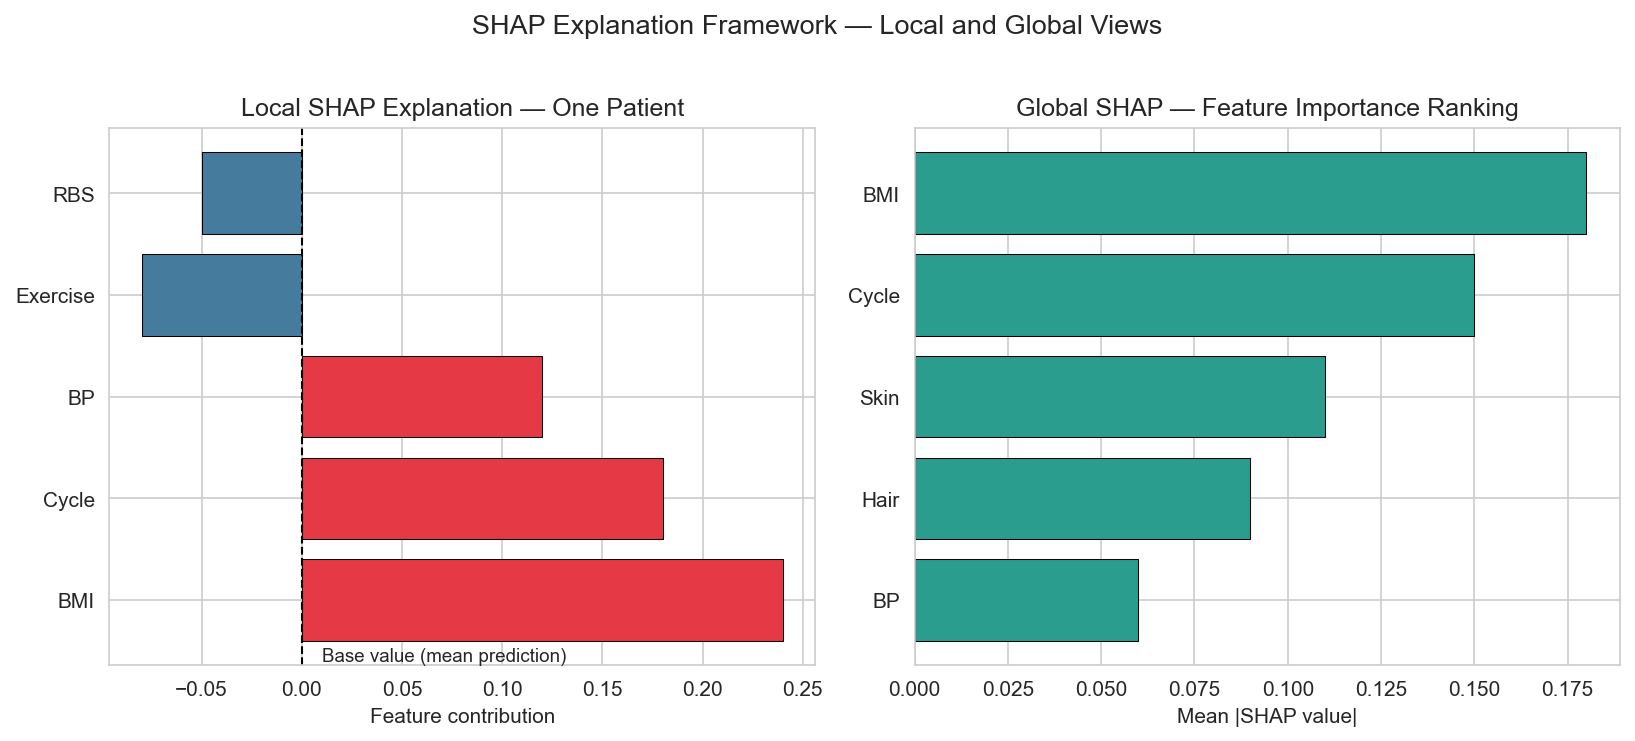

In [136]:
# Creating the main SHAP concept diagram is introducing the difference between local and global explanations.
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

local_features = ['BMI', 'Cycle', 'BP', 'Exercise', 'RBS']
local_values = [0.24, 0.18, 0.12, -0.08, -0.05]
local_colors = [COLORS['shap_pos'] if v > 0 else COLORS['shap_neg'] for v in local_values]
axes[0].barh(local_features, local_values, color=local_colors, edgecolor='black', linewidth=0.5)
axes[0].axvline(0, linestyle='--', color='black', linewidth=1)
axes[0].text(0.01, -0.6, 'Base value (mean prediction)', fontsize=9)
axes[0].annotate('Final prediction', xy=(0.30, 4.2), xytext=(0.18, 4.7), arrowprops=dict(arrowstyle='->', color='black'))
axes[0].set_title('Local SHAP Explanation — One Patient')
axes[0].set_xlabel('Feature contribution')

global_features = ['BMI', 'Cycle', 'Skin', 'Hair', 'BP']
global_importance = [0.18, 0.15, 0.11, 0.09, 0.06]
axes[1].barh(global_features[::-1], global_importance[::-1], color=COLORS['model1'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Global SHAP — Feature Importance Ranking')
axes[1].set_xlabel('Mean |SHAP value|')

plt.suptitle('SHAP Explanation Framework — Local and Global Views', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / '01_shap_concept_diagram.png', bbox_inches='tight')
plt.show()


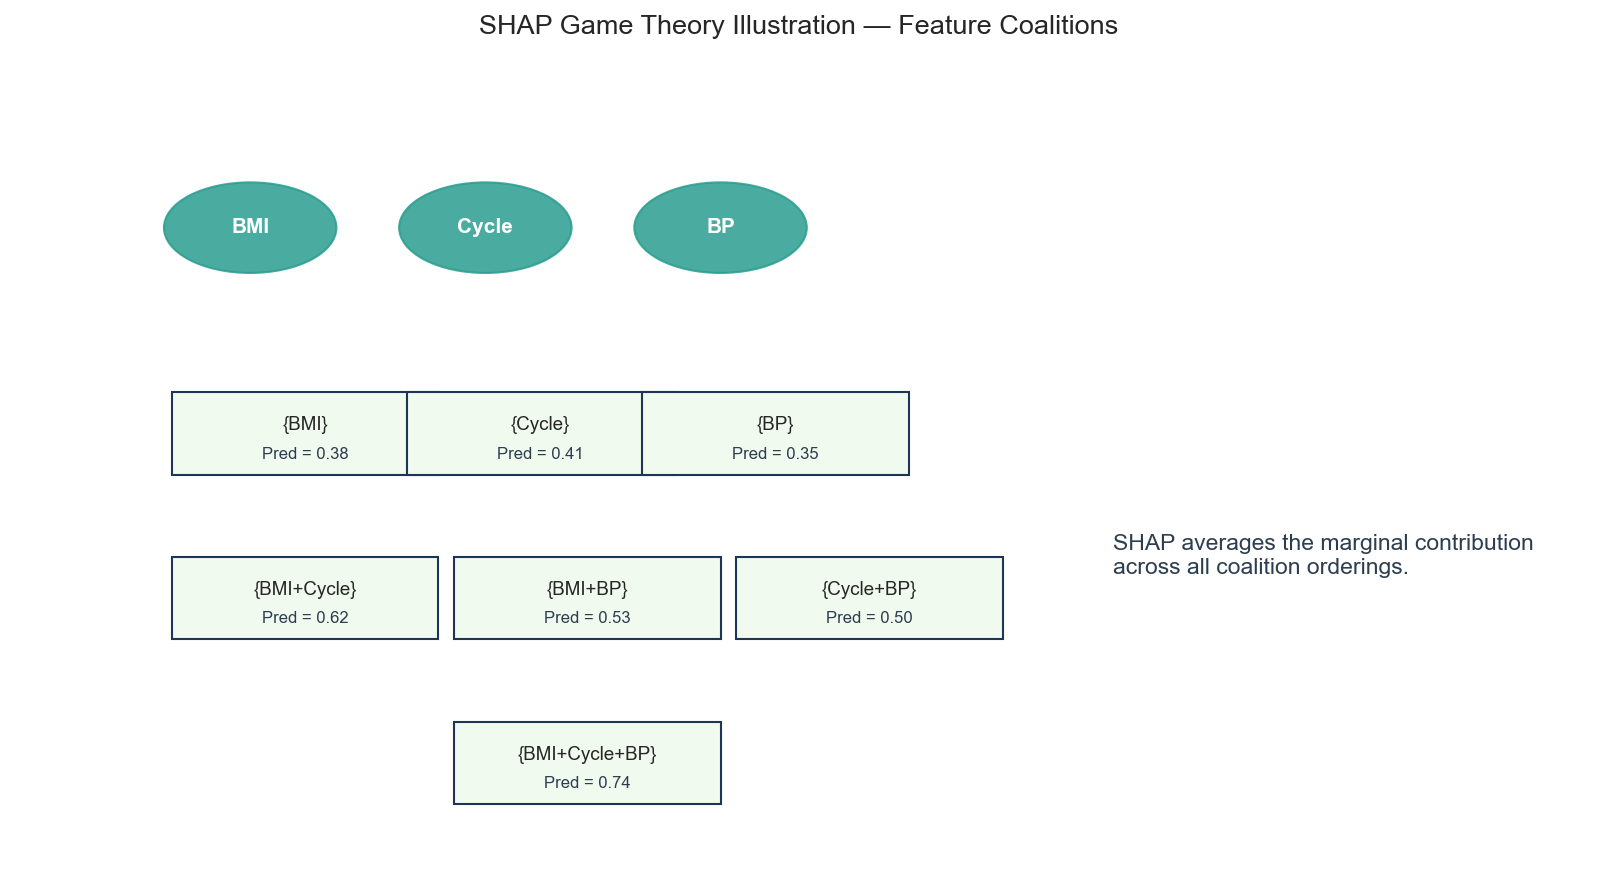

In [137]:
# Creating the game-theory illustration is showing how feature coalitions build the SHAP idea.
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis('off')

circles = [('BMI', (0.15, 0.78)), ('Cycle', (0.30, 0.78)), ('BP', (0.45, 0.78))]
for label, (x, y) in circles:
    circ = plt.Circle((x, y), 0.055, color=COLORS['model1'], alpha=0.85)
    ax.add_patch(circ)
    ax.text(x, y, label, color='white', ha='center', va='center', fontsize=10, fontweight='bold')

coalition_boxes = [
    ('{BMI}', 0.10, 0.48, '0.38'),
    ('{Cycle}', 0.25, 0.48, '0.41'),
    ('{BP}', 0.40, 0.48, '0.35'),
    ('{BMI+Cycle}', 0.10, 0.28, '0.62'),
    ('{BMI+BP}', 0.28, 0.28, '0.53'),
    ('{Cycle+BP}', 0.46, 0.28, '0.50'),
    ('{BMI+Cycle+BP}', 0.28, 0.08, '0.74'),
]
for label, x, y, score in coalition_boxes:
    rect = plt.Rectangle((x, y), 0.17, 0.10, fill=True, color='#F1FAEE', ec='#1D3557', lw=1.0)
    ax.add_patch(rect)
    ax.text(x + 0.085, y + 0.06, label, ha='center', va='center', fontsize=9)
    ax.text(x + 0.085, y + 0.025, f'Pred = {score}', ha='center', va='center', fontsize=8, color=COLORS['neutral'])

ax.text(0.70, 0.36, 'SHAP averages the marginal contribution\nacross all coalition orderings.', fontsize=11, color=COLORS['neutral'])
ax.set_title('SHAP Game Theory Illustration — Feature Coalitions', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / '02_shap_game_theory_illustration.png', bbox_inches='tight')
plt.show()


## Section 3 — Explaining Model 1

This section is explaining the final optimized non-invasive screening model. The model uses 19 routine features that can be collected without hormonal testing or ultrasound. The saved optimized bundle is the source of truth, and the saved JSON file is providing the optimizer name and the final reported test metrics.


**Scientific meaning:** This section is using SHAP to explain the final non-invasive PCOS model. The analysis is showing which routine screening features are pushing the prediction up or down across the clinical test patients.

**Simple summary:** This part is showing what the final non-invasive model is paying attention to.

**Why this matters:** If the top features make clinical sense, the model is easier to trust and easier to explain to clinicians and patients.


In [138]:
# Loading the saved final optimized Model 1 bundle is making the explainability section use the deployed model artifact directly.
print('Saved best-parameter JSON:')
print(json.dumps(m1_best, indent=2))
print()
print('Saved optimized model test results:')
print(final_bundle_m1['test_results'])
print()
print('Saved stack family:')
print(final_bundle_m1['stack_family'])
print()
print('Saved feature count:')
print(len(final_bundle_m1['feature_names']))


Saved best-parameter JSON:
{
  "optimizer": "CSO",
  "stack_family": "lr",
  "auc": 0.95475221185433,
  "params": {
    "rf_n_estimators": 479.0,
    "rf_max_depth": 20.0,
    "rf_min_samples_split": 2.0,
    "xgb_n_estimators": 400.0,
    "xgb_learning_rate": 0.01,
    "xgb_max_depth": 2.0,
    "xgb_subsample": 1.0,
    "meta_C": 10.0,
    "meta_n_estimators": 300.0
  }
}

Saved optimized model test results:
{'model': 'Model 1 - CSO Optimized', 'accuracy': 0.8623853211009175, 'precision': 0.8387096774193549, 'recall': 0.7222222222222222, 'f1': 0.7761194029850746, 'auc': 0.91324200913242}

Saved stack family:
lr

Saved feature count:
19


In [139]:
# Running the saved final optimized Model 1 bundle on the test set is confirming that the loaded artifact reproduces its saved metrics.
test_meta_m1, y_m1_proba = stack_predict_proba(final_bundle_m1, X1_test)
threshold_m1 = float(final_bundle_m1.get('threshold', 0.5))
y_m1_pred = (y_m1_proba >= threshold_m1).astype(int)
results_m1_final = evaluate_prediction('Model 1 Final Optimized', y1_test, y_m1_pred, y_m1_proba)
results_m1_check = pd.DataFrame([
    {'source': 'Saved bundle', **final_bundle_m1['test_results']},
    {'source': 'Notebook 11 rerun', **results_m1_final}
])
print(results_m1_check.to_string(index=False))


           source                   model  accuracy  precision   recall       f1      auc
     Saved bundle Model 1 - CSO Optimized  0.862385    0.83871 0.722222 0.776119 0.913242
Notebook 11 rerun Model 1 Final Optimized  0.862385    0.83871 0.722222 0.776119 0.913242


In [140]:
# Building test DataFrames is making the SHAP plotting cells easier to read and easier to label.
m1_test_df = pd.DataFrame(X1_test, columns=MODEL1_FEATURES)
m1_train_df = pd.DataFrame(X1_train, columns=MODEL1_FEATURES)
print(m1_test_df.head().to_string(index=False))


 age_yrs      bmi  cycle_regularity_binary  cycle_length_days  weight_gain_y_n  hair_growth_y_n  skin_darkening_y_n  hair_loss_y_n  pimples_y_n  fast_food_y_n  regular_exercise_y_n  systolic_bp_mmhg  diastolic_bp_mmhg  waist_hip_ratio  rbs_mg_dl  symptom_burden  bmi_category  bp_elevated_flag  lifestyle_risk
0.250000 0.403371                      1.0                0.3              0.0              0.0                 0.0            0.0          0.0            1.0                   1.0              0.50                0.5         0.584475   0.200000             0.0      0.333333               1.0             0.5
0.535714 0.527983                      1.0                0.2              0.0              0.0                 0.0            0.0          0.0            1.0                   0.0              0.50                0.5         0.977871   0.242424             0.0      0.666667               1.0             1.0
0.321429 0.612952                      1.0                0.3         

In [141]:
# Computing TreeSHAP values from the saved Random Forest base learner is producing the main explanation layer for Model 1.
rf_m1 = final_bundle_m1['base_models']['rf']
explainer_m1 = shap.TreeExplainer(rf_m1)
shap_values_raw_m1 = explainer_m1.shap_values(X1_test)
sv_m1 = extract_positive_shap(shap_values_raw_m1)
expected_value_m1 = extract_positive_expected_value(explainer_m1.expected_value)
explanation_m1 = shap.Explanation(
    values=sv_m1,
    base_values=np.repeat(expected_value_m1, sv_m1.shape[0]),
    data=X1_test,
    feature_names=MODEL1_FEATURES,
)
np.save(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_values_model1.npy', sv_m1)
print('SHAP matrix shape:')
print(sv_m1.shape)
print()
print('Saved file:')
print(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_values_model1.npy')


SHAP matrix shape:
(109, 19)

Saved file:
C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\shap_values_model1.npy


In [142]:
# Building the SHAP ranking table is summarizing how important each Model 1 feature is on average.
mean_abs_shap_m1 = np.abs(sv_m1).mean(axis=0)
shap_rank_m1 = pd.DataFrame({
    'feature': MODEL1_FEATURES,
    'mean_abs_shap': mean_abs_shap_m1,
    'mean_shap': sv_m1.mean(axis=0),
    'positive_impact_share': (sv_m1 > 0).mean(axis=0),
    'negative_impact_share': (sv_m1 < 0).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_rank_m1.insert(0, 'rank', np.arange(1, len(shap_rank_m1) + 1))
shap_rank_m1.to_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_feature_ranking_model1.csv', index=False)
print(shap_rank_m1.to_string(index=False))


 rank                 feature  mean_abs_shap  mean_shap  positive_impact_share  negative_impact_share
    1          symptom_burden       0.127385  -0.034956               0.348624               0.651376
    2       cycle_length_days       0.056898  -0.020066               0.256881               0.743119
    3         weight_gain_y_n       0.055814  -0.005686               0.449541               0.550459
    4      skin_darkening_y_n       0.050289  -0.011996               0.302752               0.697248
    5 cycle_regularity_binary       0.046970  -0.016412               0.247706               0.752294
    6         hair_growth_y_n       0.044025  -0.007746               0.293578               0.706422
    7           fast_food_y_n       0.033717  -0.007508               0.504587               0.495413
    8                 age_yrs       0.030163  -0.004898               0.495413               0.504587
    9             pimples_y_n       0.024530  -0.009797               0.431193    

### Global SHAP Explanation — Model 1

This section is answering one main question: across all test patients, which features are mattering most on average? The mean absolute SHAP value is showing average importance, while the sign of the SHAP values is showing whether a feature is usually pushing the prediction toward PCOS or away from PCOS.


In [143]:
# Printing the global SHAP ranking table is showing the exact data used for the bar chart.
global_bar_m1 = shap_rank_m1[['rank', 'feature', 'mean_abs_shap']].copy()
print(global_bar_m1.to_string(index=False))


 rank                 feature  mean_abs_shap
    1          symptom_burden       0.127385
    2       cycle_length_days       0.056898
    3         weight_gain_y_n       0.055814
    4      skin_darkening_y_n       0.050289
    5 cycle_regularity_binary       0.046970
    6         hair_growth_y_n       0.044025
    7           fast_food_y_n       0.033717
    8                 age_yrs       0.030163
    9             pimples_y_n       0.024530
   10          lifestyle_risk       0.017952
   11         waist_hip_ratio       0.014510
   12                     bmi       0.013278
   13    regular_exercise_y_n       0.012907
   14               rbs_mg_dl       0.012486
   15            bmi_category       0.011238
   16        bp_elevated_flag       0.009125
   17       diastolic_bp_mmhg       0.008412
   18           hair_loss_y_n       0.005197
   19        systolic_bp_mmhg       0.004936


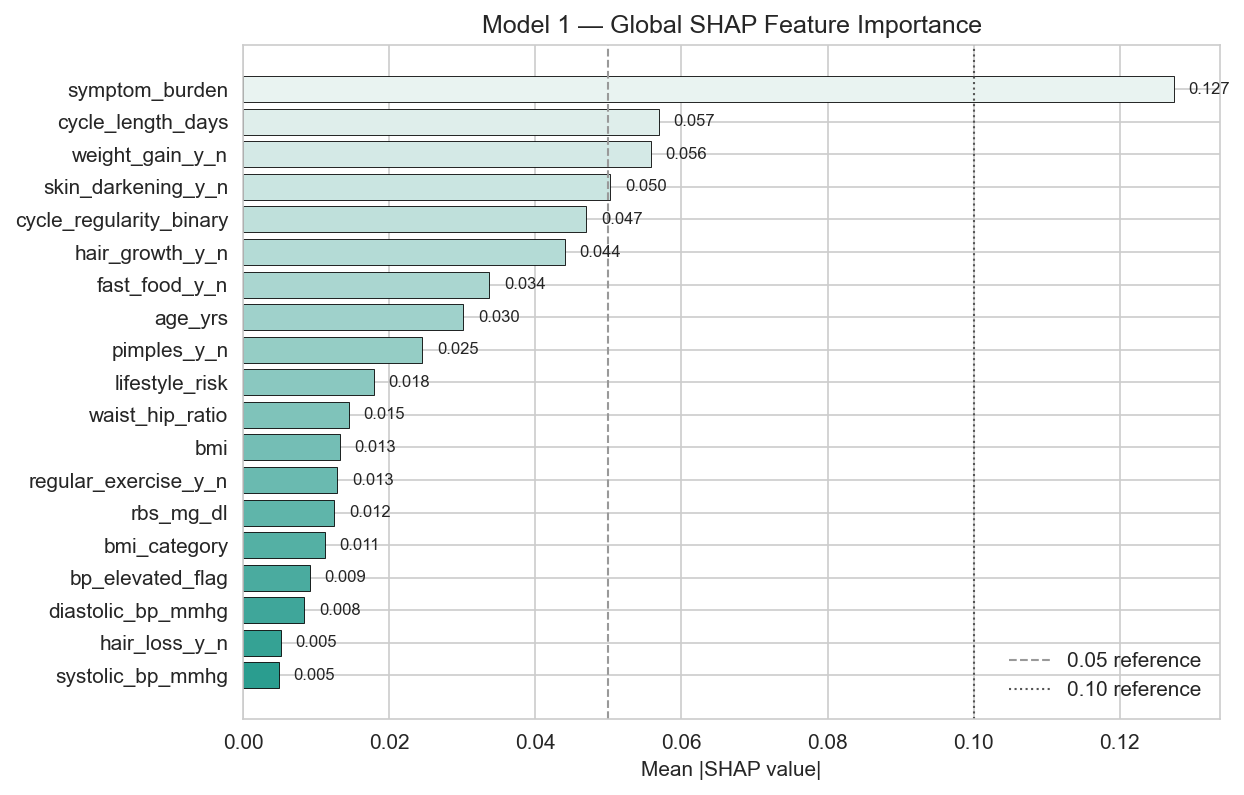

In [144]:
# Plotting the global SHAP bar chart is showing the average absolute contribution of each Model 1 feature.
fig, ax = plt.subplots(figsize=(8.4, 5.4))
plot_df = global_bar_m1.sort_values('mean_abs_shap', ascending=True)
colors = sns.light_palette(COLORS['model1'], n_colors=len(plot_df), reverse=True)
bars = ax.barh(plot_df['feature'], plot_df['mean_abs_shap'], color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(0.05, color='#999999', linestyle='--', linewidth=1, label='0.05 reference')
ax.axvline(0.10, color='#555555', linestyle=':', linewidth=1, label='0.10 reference')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Model 1 — Global SHAP Feature Importance')
for bar, value in zip(bars, plot_df['mean_abs_shap']):
    ax.text(value + 0.002, bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center', fontsize=8)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '03_m1_shap_bar_global.png', bbox_inches='tight')
plt.show()


### Global Bar Chart Insight

This chart is showing the features with the strongest average effect on the prediction. Features at the top of the chart are the ones the model is using most often. This matters because these are the features you would mention first when explaining how the model works.


In [145]:
# Printing the beeswarm support table is showing the average SHAP direction for high and low feature values before plotting.
beeswarm_summary_m1 = []
for feature in MODEL1_FEATURES:
    values = m1_test_df[feature].values
    shap_col = sv_m1[:, MODEL1_FEATURES.index(feature)]
    median_value = float(np.nanmedian(values))
    high_mask = values >= median_value
    low_mask = values < median_value
    beeswarm_summary_m1.append({
        'feature': feature,
        'median_value': median_value,
        'mean_shap_high_values': float(np.nanmean(shap_col[high_mask])) if high_mask.any() else np.nan,
        'mean_shap_low_values': float(np.nanmean(shap_col[low_mask])) if low_mask.any() else np.nan,
    })
beeswarm_summary_m1 = pd.DataFrame(beeswarm_summary_m1).sort_values('feature')
print(beeswarm_summary_m1.round(4).to_string(index=False))


                feature  median_value  mean_shap_high_values  mean_shap_low_values
                age_yrs        0.3929                -0.0322                0.0261
                    bmi        0.4525                 0.0062               -0.0097
           bmi_category        0.3333                -0.0076                0.0055
       bp_elevated_flag        1.0000                -0.0087                0.0105
      cycle_length_days        0.3000                -0.0494                0.0786
cycle_regularity_binary        1.0000                -0.0421                0.0617
      diastolic_bp_mmhg        0.5000                -0.0075                0.0113
          fast_food_y_n        1.0000                 0.0260               -0.0416
        hair_growth_y_n        0.0000                -0.0077                   NaN
          hair_loss_y_n        0.0000                -0.0026                   NaN
         lifestyle_risk        0.5000                -0.0079                0.0138
    

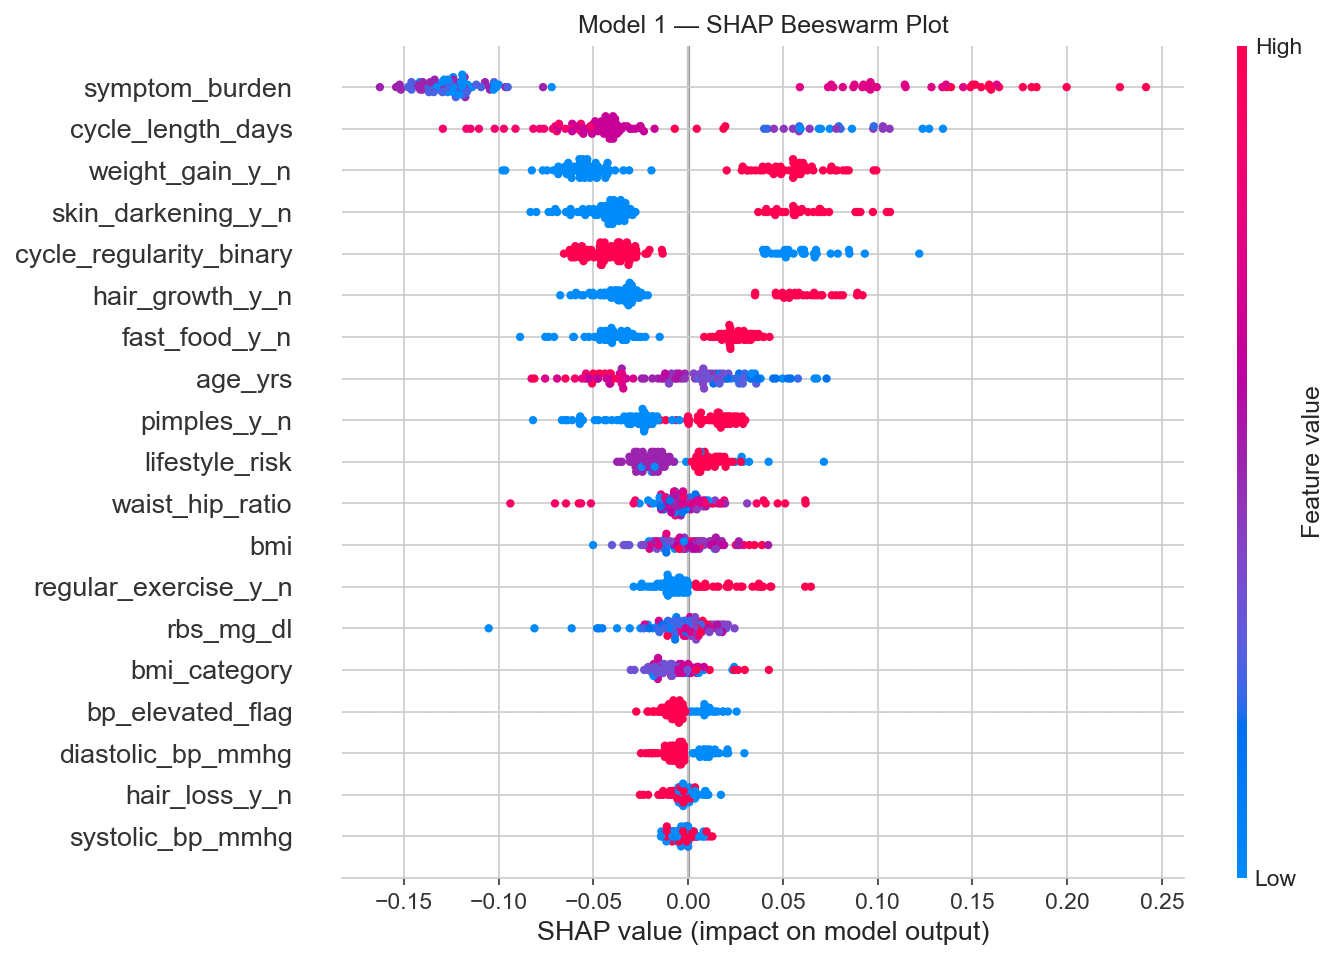

In [146]:
# Plotting the beeswarm view is showing both SHAP direction and patient-level spread for Model 1.
shap.summary_plot(sv_m1, m1_test_df, feature_names=MODEL1_FEATURES, show=False, plot_size=(9.5, 6.5))
plt.title('Model 1 — SHAP Beeswarm Plot')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '04_m1_shap_beeswarm.png', bbox_inches='tight')
plt.show()


### Reading the Beeswarm Plot — Model 1

Each dot is one patient. The horizontal position is showing how much that feature pushed the prediction toward PCOS on the right or away from PCOS on the left. The colour is showing whether that patient's feature value was high or low. When red dots sit more on the right and blue dots sit more on the left, it means higher values of that feature are usually increasing the model's PCOS risk estimate.


In [147]:
# Printing SHAP summary statistics is showing the exact matrix summary used before the heatmap.
shap_stats_m1 = pd.DataFrame({
    'feature': MODEL1_FEATURES,
    'mean': sv_m1.mean(axis=0),
    'std': sv_m1.std(axis=0),
    'min': sv_m1.min(axis=0),
    'max': sv_m1.max(axis=0),
})
print(shap_stats_m1.round(4).to_string(index=False))


                feature    mean    std     min    max
                age_yrs -0.0049 0.0358 -0.0826 0.0731
                    bmi -0.0015 0.0167 -0.0501 0.0422
cycle_regularity_binary -0.0164 0.0469 -0.0655 0.1220
      cycle_length_days -0.0201 0.0596 -0.1294 0.1345
        weight_gain_y_n -0.0057 0.0576 -0.0979 0.0993
        hair_growth_y_n -0.0077 0.0462 -0.0675 0.0921
     skin_darkening_y_n -0.0120 0.0516 -0.0831 0.1066
          hair_loss_y_n -0.0026 0.0065 -0.0255 0.0173
            pimples_y_n -0.0098 0.0271 -0.0818 0.0302
          fast_food_y_n -0.0075 0.0355 -0.0887 0.0430
   regular_exercise_y_n  0.0004 0.0179 -0.0287 0.0648
       systolic_bp_mmhg -0.0028 0.0057 -0.0143 0.0128
      diastolic_bp_mmhg -0.0028 0.0096 -0.0249 0.0297
        waist_hip_ratio -0.0029 0.0224 -0.0938 0.0620
              rbs_mg_dl -0.0040 0.0194 -0.1052 0.0245
         symptom_burden -0.0350 0.1260 -0.1626 0.2416
           bmi_category -0.0068 0.0120 -0.0303 0.0426
       bp_elevated_flag -0.0

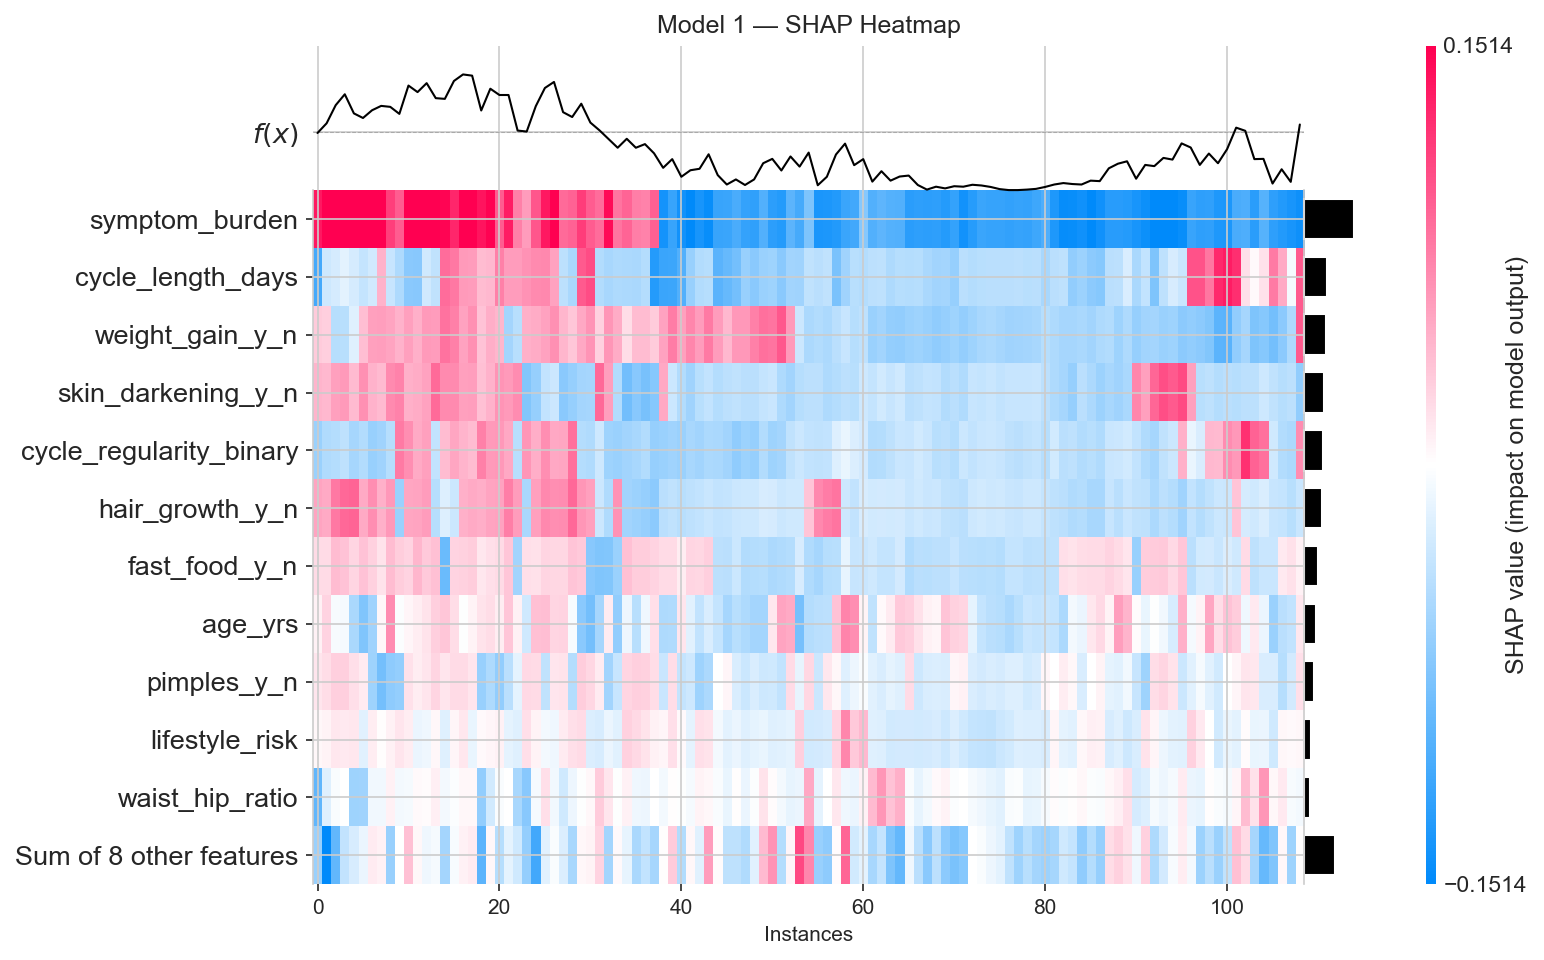

In [148]:
# Plotting the SHAP heatmap is showing whether groups of patients share similar explanation patterns.
shap.plots.heatmap(explanation_m1, show=False, max_display=min(12, len(MODEL1_FEATURES)))
plt.gcf().set_size_inches(10, 6.5)
plt.title('Model 1 — SHAP Heatmap')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '05_m1_shap_heatmap.png', bbox_inches='tight')
plt.show()


### Heatmap Insight

This heatmap is showing whether some patients share similar explanation patterns. If blocks of colour appear together, that suggests the model is seeing clusters of patients with similar feature-driven risk patterns.


### Local SHAP Explanation — Model 1

This section is moving from the population view to the patient view. Three cases are being checked: a true positive, a false negative, and a false positive. This is showing why the final stack got a patient right, why it missed a case, and why it raised a false alarm.


In [149]:
# Selecting one true positive, one false negative, and one false positive is preparing the local explanation cases.
selected_cases_m1 = select_case_indices(y1_test, y_m1_pred, y_m1_proba)
print('Case counts:')
print(f"  TP count: {selected_cases_m1['tp_count']}")
print(f"  FN count: {selected_cases_m1['fn_count']}")
print(f"  FP count: {selected_cases_m1['fp_count']}")
print()
print('Selected indices:')
print(selected_cases_m1)


Case counts:
  TP count: 26
  FN count: 10
  FP count: 5

Selected indices:
{'tp_idx': 41, 'fn_idx': 82, 'fp_idx': 23, 'tp_count': 26, 'fn_count': 10, 'fp_count': 5}


In [150]:
# Printing the selected patient feature values is showing the raw profile behind each local explanation.
patient_cases_m1 = m1_test_df.copy()
for case_label in ['tp', 'fn', 'fp']:
    idx = selected_cases_m1[f'{case_label}_idx']
    print(case_label.upper(), 'patient values')
    print(patient_cases_m1.iloc[idx].to_string())
    print(f"Predicted probability: {y_m1_proba[idx]:.4f}")
    print(f"Actual label: {int(y1_test[idx])} | Predicted label: {int(y_m1_pred[idx])}")
    print('-' * 60)


TP patient values
age_yrs                    0.428571
bmi                        0.645044
cycle_regularity_binary    0.000000
cycle_length_days          0.100000
weight_gain_y_n            1.000000
hair_growth_y_n            1.000000
skin_darkening_y_n         1.000000
hair_loss_y_n              0.000000
pimples_y_n                1.000000
fast_food_y_n              1.000000
regular_exercise_y_n       0.000000
systolic_bp_mmhg           0.500000
diastolic_bp_mmhg          0.500000
waist_hip_ratio            0.657534
rbs_mg_dl                  0.272727
symptom_burden             0.800000
bmi_category               0.666667
bp_elevated_flag           1.000000
lifestyle_risk             1.000000
Predicted probability: 0.9776
Actual label: 1 | Predicted label: 1
------------------------------------------------------------
FN patient values
age_yrs                    0.428571
bmi                        0.403371
cycle_regularity_binary    1.000000
cycle_length_days          0.300000
weight_g

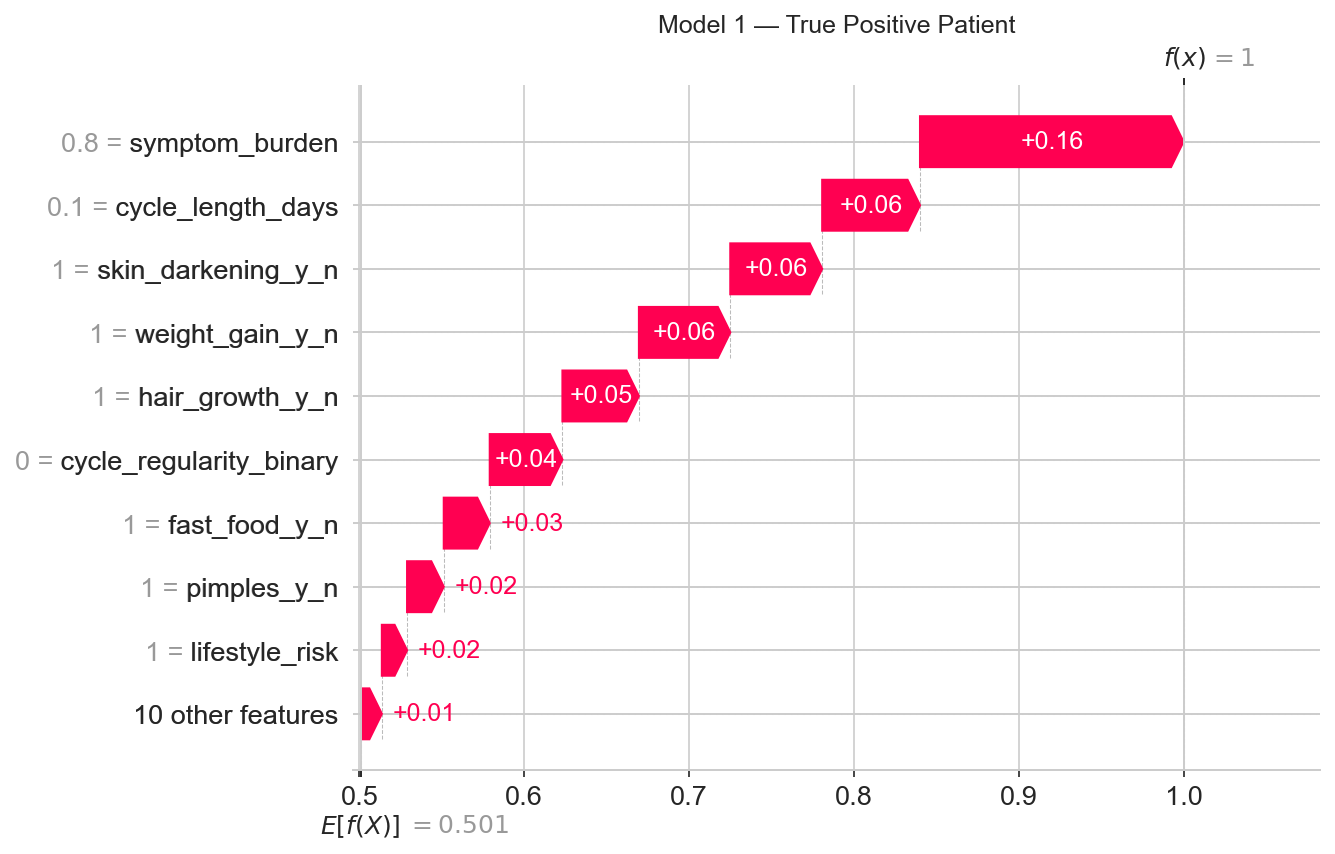

In [151]:
# Plotting the true positive waterfall is showing which features pushed this case up or down.
tp_idx_m1 = selected_cases_m1['tp_idx']
tp_explanation_m1 = shap.Explanation(
    values=sv_m1[tp_idx_m1],
    base_values=expected_value_m1,
    data=X1_test[tp_idx_m1],
    feature_names=MODEL1_FEATURES,
)
shap.plots.waterfall(tp_explanation_m1, show=False)
plt.gcf().set_size_inches(9, 5.8)
plt.title('Model 1 — True Positive Patient')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '06_m1_shap_waterfall_true_positive.png', bbox_inches='tight')
plt.show()


### True Positive Waterfall Insight

This waterfall is showing how the final score moved from the base value to the patient's final prediction. Features pushing to the right are raising risk, and features pushing to the left are lowering risk. This matters because it shows the exact feature mix behind a correct call, a missed case, or a false alarm.


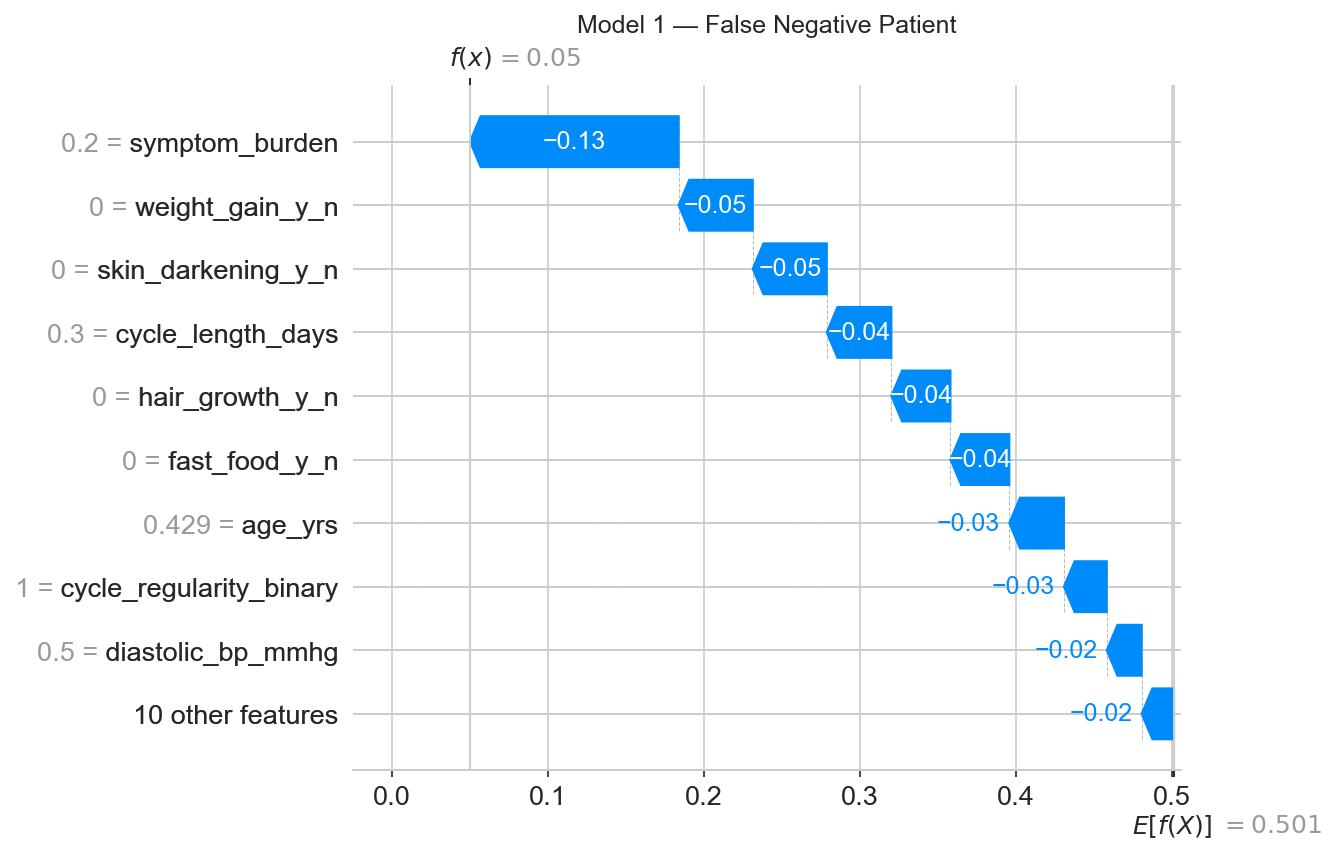

In [152]:
# Plotting the false negative waterfall is showing which features pushed this case up or down.
fn_idx_m1 = selected_cases_m1['fn_idx']
fn_explanation_m1 = shap.Explanation(
    values=sv_m1[fn_idx_m1],
    base_values=expected_value_m1,
    data=X1_test[fn_idx_m1],
    feature_names=MODEL1_FEATURES,
)
shap.plots.waterfall(fn_explanation_m1, show=False)
plt.gcf().set_size_inches(9, 5.8)
plt.title('Model 1 — False Negative Patient')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '07_m1_shap_waterfall_false_negative.png', bbox_inches='tight')
plt.show()


### False Negative Waterfall Insight

This waterfall is showing how the final score moved from the base value to the patient's final prediction. Features pushing to the right are raising risk, and features pushing to the left are lowering risk. This matters because it shows the exact feature mix behind a correct call, a missed case, or a false alarm.


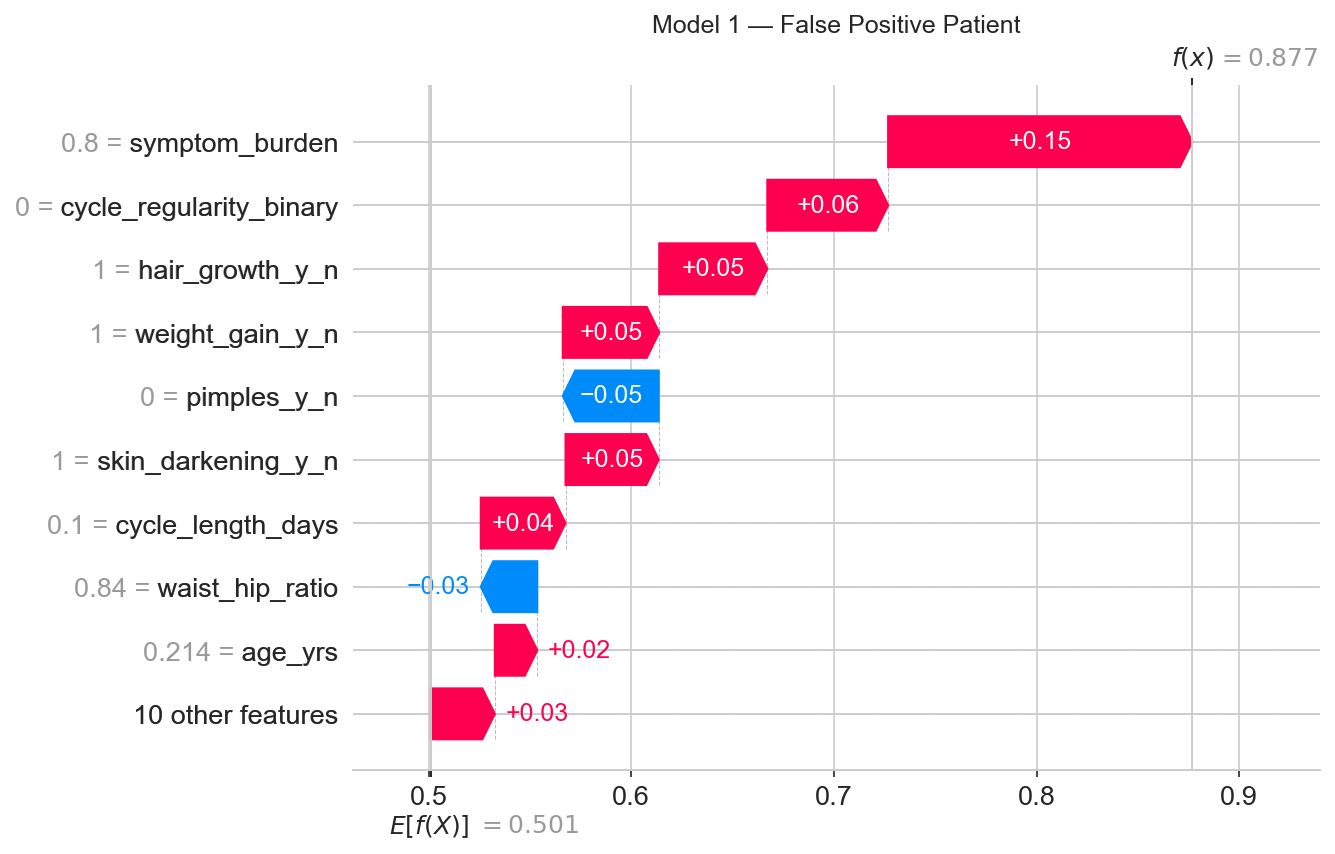

In [153]:
# Plotting the false positive waterfall is showing which features pushed this case up or down.
fp_idx_m1 = selected_cases_m1['fp_idx']
fp_explanation_m1 = shap.Explanation(
    values=sv_m1[fp_idx_m1],
    base_values=expected_value_m1,
    data=X1_test[fp_idx_m1],
    feature_names=MODEL1_FEATURES,
)
shap.plots.waterfall(fp_explanation_m1, show=False)
plt.gcf().set_size_inches(9, 5.8)
plt.title('Model 1 — False Positive Patient')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '08_m1_shap_waterfall_false_positive.png', bbox_inches='tight')
plt.show()


### False Positive Waterfall Insight

This waterfall is showing how the final score moved from the base value to the patient's final prediction. Features pushing to the right are raising risk, and features pushing to the left are lowering risk. This matters because it shows the exact feature mix behind a correct call, a missed case, or a false alarm.


### SHAP Dependence Plots — Model 1

Dependence plots are showing how the value of a feature is relating to its SHAP contribution across patients. This helps answer whether the effect is roughly linear, threshold-based, or more mixed.


In [154]:
# Printing the top three SHAP features is selecting the features used for the dependence plots.
top3_m1 = shap_rank_m1.head(3)['feature'].tolist()
top3_table_m1 = shap_rank_m1.head(3)[['rank', 'feature', 'mean_abs_shap']]
print(top3_table_m1.to_string(index=False))


 rank           feature  mean_abs_shap
    1    symptom_burden       0.127385
    2 cycle_length_days       0.056898
    3   weight_gain_y_n       0.055814


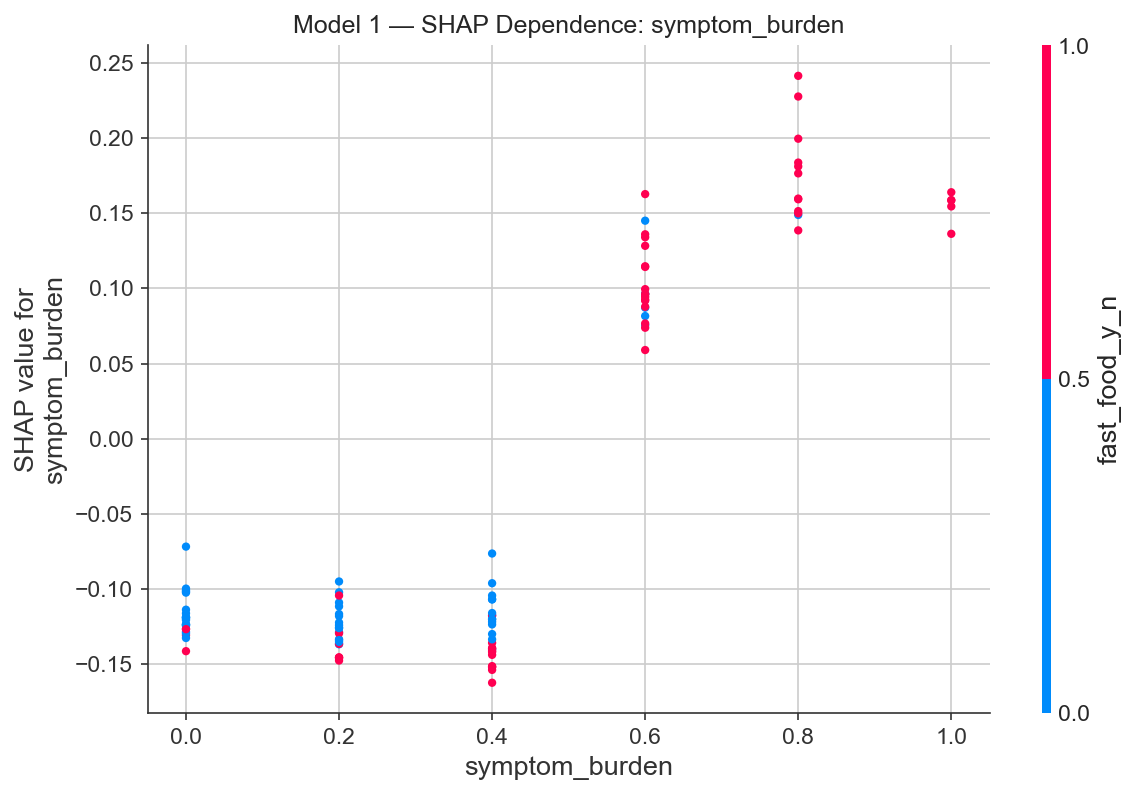

In [155]:
# Plotting dependence feature 1 is showing how one top feature changes its SHAP contribution across patients.
feature_m1_1 = top3_m1[0]
shap.dependence_plot(feature_m1_1, sv_m1, m1_test_df, feature_names=MODEL1_FEATURES, interaction_index='auto', show=False)
plt.gcf().set_size_inches(8.2, 5.4)
plt.title('Model 1 — SHAP Dependence: ' + feature_m1_1)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '09_m1_shap_dependence_feature1.png', bbox_inches='tight')
plt.show()


### Dependence Plot Insight

This dependence plot is showing how the feature value and the SHAP effect move together. A smooth upward or downward pattern suggests a more monotonic effect, while a scattered pattern suggests a more mixed or threshold-like effect.


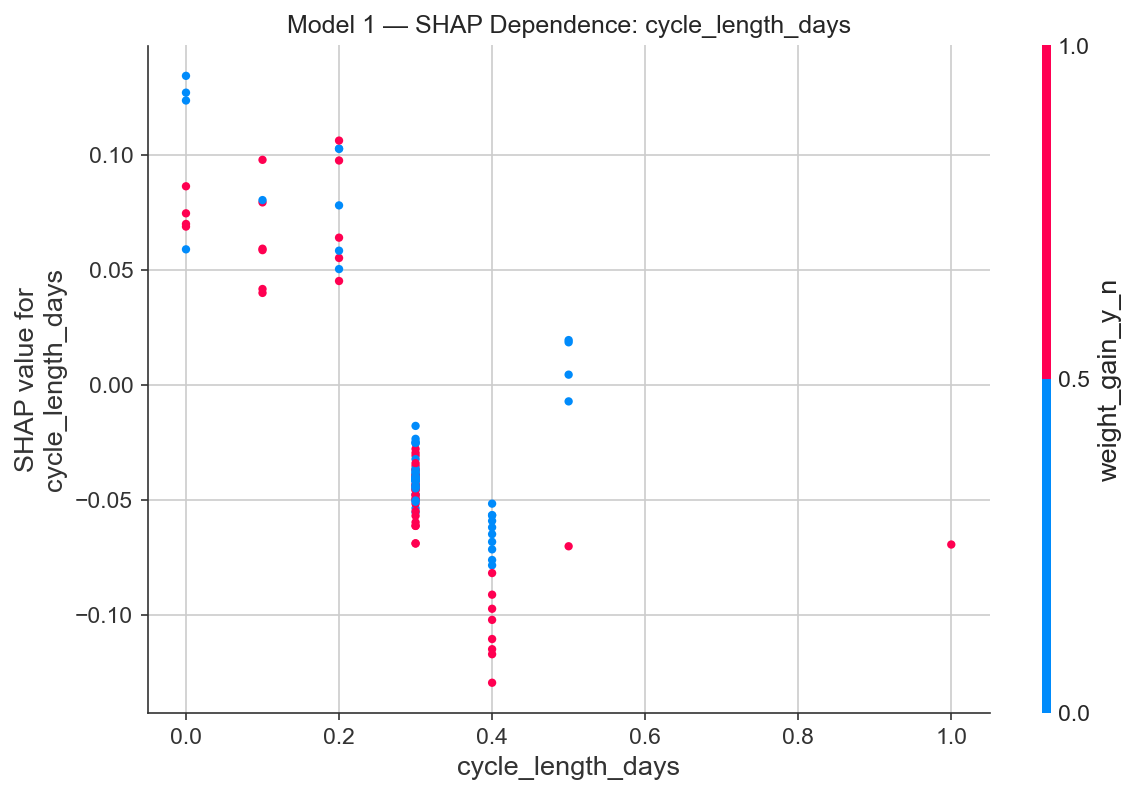

In [156]:
# Plotting dependence feature 2 is showing how one top feature changes its SHAP contribution across patients.
feature_m1_2 = top3_m1[1]
shap.dependence_plot(feature_m1_2, sv_m1, m1_test_df, feature_names=MODEL1_FEATURES, interaction_index='auto', show=False)
plt.gcf().set_size_inches(8.2, 5.4)
plt.title('Model 1 — SHAP Dependence: ' + feature_m1_2)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '10_m1_shap_dependence_feature2.png', bbox_inches='tight')
plt.show()


### Dependence Plot Insight

This dependence plot is showing how the feature value and the SHAP effect move together. A smooth upward or downward pattern suggests a more monotonic effect, while a scattered pattern suggests a more mixed or threshold-like effect.


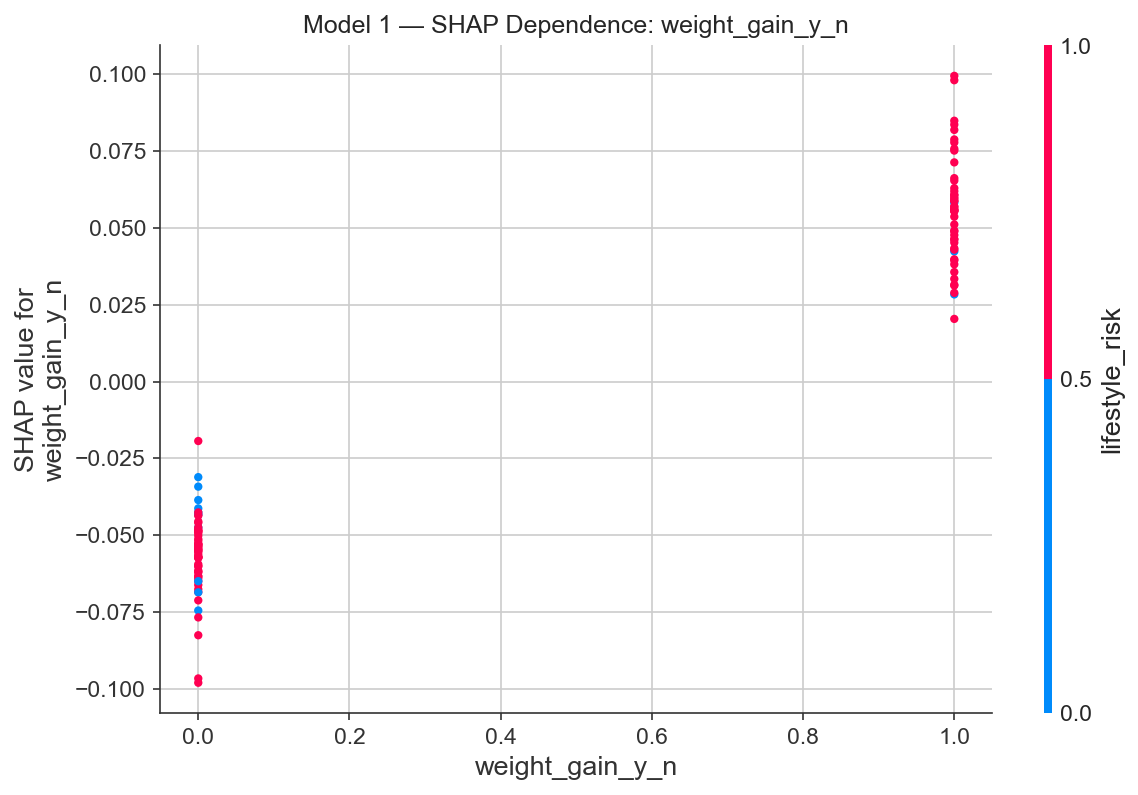

In [157]:
# Plotting dependence feature 3 is showing how one top feature changes its SHAP contribution across patients.
feature_m1_3 = top3_m1[2]
shap.dependence_plot(feature_m1_3, sv_m1, m1_test_df, feature_names=MODEL1_FEATURES, interaction_index='auto', show=False)
plt.gcf().set_size_inches(8.2, 5.4)
plt.title('Model 1 — SHAP Dependence: ' + feature_m1_3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '11_m1_shap_dependence_feature3.png', bbox_inches='tight')
plt.show()


### Dependence Plot Insight

This dependence plot is showing how the feature value and the SHAP effect move together. A smooth upward or downward pattern suggests a more monotonic effect, while a scattered pattern suggests a more mixed or threshold-like effect.


In [158]:
# Printing the interaction support table is showing the exact grouped data used before the interaction plot.
idx_a_m1 = MODEL1_FEATURES.index('bmi')
idx_b_m1 = MODEL1_FEATURES.index('cycle_regularity_binary')
interaction_df_m1 = pd.DataFrame({
    'feature_a_value': X1_test[:, idx_a_m1],
    'feature_a_shap': sv_m1[:, idx_a_m1],
    'feature_b_value': X1_test[:, idx_b_m1],
})
if 'cycle_regularity_binary' == 'cycle_regularity_binary':
    interaction_df_m1['feature_b_group'] = interaction_df_m1['feature_b_value'].map({0: 'Irregular', 1: 'Regular'}).fillna('Unknown')
else:
    interaction_df_m1['feature_b_group'] = pd.qcut(
        interaction_df_m1['feature_b_value'],
        q=2,
        labels=['Lower', 'Higher'],
        duplicates='drop',
    )
interaction_groups_m1 = interaction_df_m1.groupby('feature_b_group')[['feature_a_value', 'feature_a_shap']].describe().round(3)
print(interaction_groups_m1.to_string())


                feature_a_value                                                  feature_a_shap                                                
                          count   mean    std    min    25%    50%    75%    max          count   mean    std   min    25%    50%    75%    max
feature_b_group                                                                                                                                
Irregular                  27.0  0.501  0.152  0.199  0.400  0.492  0.582  0.986           27.0 -0.006  0.016 -0.04 -0.015 -0.002  0.004  0.019
Regular                    82.0  0.444  0.143  0.041  0.374  0.451  0.513  0.813           82.0 -0.000  0.017 -0.05 -0.012 -0.003  0.012  0.042


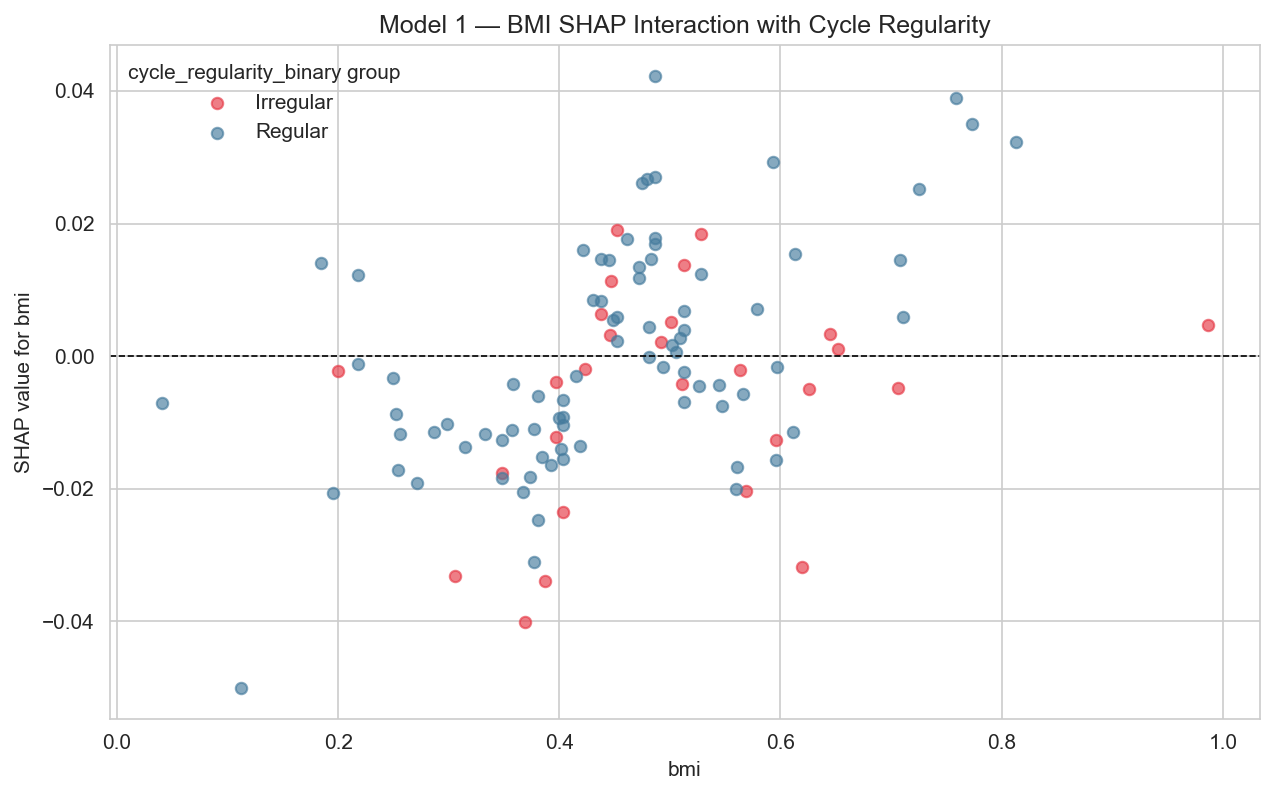

In [159]:
# Plotting the main interaction view is checking whether feature A is acting differently at different levels of feature B.
interaction_plot_df_m1 = interaction_df_m1.copy()
fig, ax = plt.subplots(figsize=(8.6, 5.4))
if 'cycle_regularity_binary' == 'cycle_regularity_binary':
    palette = {'Irregular': COLORS['shap_pos'], 'Regular': COLORS['shap_neg'], 'Unknown': COLORS['neutral']}
else:
    palette = {'Lower': COLORS['shap_neg'], 'Higher': COLORS['shap_pos']}
for group_name, group_df in interaction_plot_df_m1.groupby('feature_b_group'):
    ax.scatter(
        group_df['feature_a_value'],
        group_df['feature_a_shap'],
        s=30,
        alpha=0.65,
        color=palette[str(group_name)],
        label=str(group_name),
    )
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('bmi')
ax.set_ylabel('SHAP value for bmi')
ax.set_title('Model 1 — BMI SHAP Interaction with Cycle Regularity')
ax.legend(title='cycle_regularity_binary group', frameon=False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '12_m1_shap_interaction_bmi_cycle.png', bbox_inches='tight')
plt.show()


### Interaction Plot Insight

This interaction plot is checking whether `bmi` becomes more or less important when `cycle_regularity_binary` changes. This matters because PCOS risk often comes from combined feature patterns rather than from isolated features.


In [160]:
# Printing the meta-learner coefficient table is showing how much the final LR meta-model trusted each base learner.
meta_coefs_m1 = final_bundle_m1['meta_model'].coef_[0]
base_names_m1 = ['Logistic Regression', 'Random Forest', 'XGBoost']
meta_weight_df_m1 = pd.DataFrame({
    'base_learner': base_names_m1,
    'coefficient': meta_coefs_m1,
    'abs_weight': np.abs(meta_coefs_m1),
}).sort_values('abs_weight', ascending=False).reset_index(drop=True)
print(meta_weight_df_m1.to_string(index=False))


       base_learner  coefficient  abs_weight
      Random Forest     9.556679    9.556679
            XGBoost    -2.536218    2.536218
Logistic Regression     0.168409    0.168409


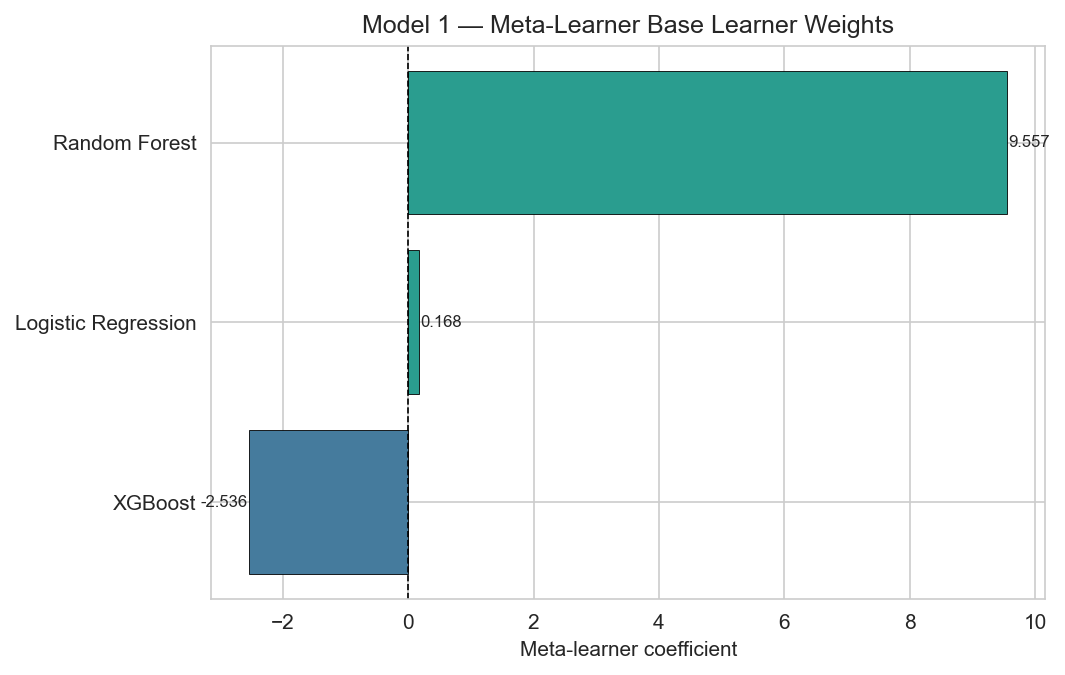

In [161]:
# Plotting the meta-learner weight chart is showing which base learner the final stack trusted most.
fig, ax = plt.subplots(figsize=(7.2, 4.6))
meta_plot_df_m1 = meta_weight_df_m1.sort_values('coefficient')
colors_m1 = [COLORS['model1'] if val >= 0 else COLORS['shap_neg'] for val in meta_plot_df_m1['coefficient']]
bars = ax.barh(meta_plot_df_m1['base_learner'], meta_plot_df_m1['coefficient'], color=colors_m1, edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Meta-learner coefficient')
ax.set_title('Model 1 — Meta-Learner Base Learner Weights')
for bar, value in zip(bars, meta_plot_df_m1['coefficient']):
    ax.text(value + (0.02 if value >= 0 else -0.02), bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center', ha='left' if value >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model1' / '13_m1_meta_base_learner_weights.png', bbox_inches='tight')
plt.show()


### Meta-Learner Weight Insight

This chart is showing how strongly the final stack is weighting each base learner. A larger absolute coefficient means the meta-learner is trusting that base learner more when it forms the final probability.


In [162]:
# Running a small Kernel SHAP fidelity check is checking whether the RF-based SHAP story broadly matches the full final stack on a small subset.
background_idx_m1 = stratified_take(y1_train, 40, seed=RANDOM_STATE)
explain_idx_m1 = stratified_take(y1_test, 30, seed=RANDOM_STATE + 1)
background_m1 = X1_train[background_idx_m1]
explain_subset_m1 = X1_test[explain_idx_m1]
kernel_explainer_m1 = shap.KernelExplainer(lambda data: stack_predict_proba(final_bundle_m1, np.asarray(data))[1], background_m1)
kernel_values_raw_m1 = kernel_explainer_m1.shap_values(explain_subset_m1, nsamples=100)
kernel_sv_m1 = extract_positive_shap(kernel_values_raw_m1)
kernel_rank_m1 = pd.DataFrame({
    'feature': MODEL1_FEATURES,
    'kernel_mean_abs_shap': np.abs(kernel_sv_m1).mean(axis=0),
}).sort_values('kernel_mean_abs_shap', ascending=False).reset_index(drop=True)
fidelity_top_m1 = kernel_rank_m1.head(5).copy()
rf_top_m1 = shap_rank_m1.head(5)[['feature', 'mean_abs_shap']].copy()
overlap_m1 = sorted(set(fidelity_top_m1['feature']) & set(rf_top_m1['feature']))
print('Kernel SHAP top five on the small stack subset:')
print(fidelity_top_m1.to_string(index=False))
print()
print('RF TreeSHAP top five on the full test set:')
print(rf_top_m1.to_string(index=False))
print()
print('Top-five overlap:')
print(overlap_m1)


  0%|          | 0/30 [00:00<?, ?it/s]

Kernel SHAP top five on the small stack subset:
                feature  kernel_mean_abs_shap
         symptom_burden              0.114789
        weight_gain_y_n              0.047613
      cycle_length_days              0.046684
cycle_regularity_binary              0.045625
     skin_darkening_y_n              0.033929

RF TreeSHAP top five on the full test set:
                feature  mean_abs_shap
         symptom_burden       0.127385
      cycle_length_days       0.056898
        weight_gain_y_n       0.055814
     skin_darkening_y_n       0.050289
cycle_regularity_binary       0.046970

Top-five overlap:
['cycle_length_days', 'cycle_regularity_binary', 'skin_darkening_y_n', 'symptom_burden', 'weight_gain_y_n']


### Full-Stack Fidelity Check

This check is not replacing the main TreeSHAP analysis. It is only checking whether the top features from the fast Random Forest explanation broadly agree with the full final stack on a small subset. If the overlap is reasonable, the main SHAP story is easier to defend.


In [163]:
# Writing the clinical summary is turning the main SHAP findings into a short explanation that can be used in the thesis discussion.
top_features_m1 = ', '.join([f"`{name}`" for name in shap_rank_m1.head(5)['feature'].tolist()])
if 'm1' == 'm2':
    marker_hits = [name for name in ['amh_ng_ml', 'fsh_lh_ratio', 'follicle_no_left', 'follicle_no_right'] if name in shap_rank_m1.head(5)['feature'].tolist()]
    marker_text = ', '.join([f"`{name}`" for name in marker_hits]) if marker_hits else 'none of the expected marker group'
    extra_text = f" Literature-linked markers appearing in the top five are: {marker_text}."
else:
    extra_text = ''
render_markdown(
    '### Model 1 Clinical Summary\n'
    f'**What the top features are:** {top_features_m1}.\n'
    f'**What the local cases show:** The selected true positive, false negative, and false positive cases are showing how the model gets a case right, misses a case, or raises a false alarm.\n'
    f'**What the interaction shows:** The interaction plot is showing whether two clinically related features are making each other stronger or weaker.\n'
    f'**Why this matters:** This gives a feature-level explanation of how model 1 is making decisions.{extra_text}\n'
    f'**Simple summary:** The SHAP results are showing the main features that the final model 1 is relying on.'
)


### Model 1 Clinical Summary
**What the top features are:** `symptom_burden`, `cycle_length_days`, `weight_gain_y_n`, `skin_darkening_y_n`, `cycle_regularity_binary`.
**What the local cases show:** The selected true positive, false negative, and false positive cases are showing how the model gets a case right, misses a case, or raises a false alarm.
**What the interaction shows:** The interaction plot is showing whether two clinically related features are making each other stronger or weaker.
**Why this matters:** This gives a feature-level explanation of how model 1 is making decisions.
**Simple summary:** The SHAP results are showing the main features that the final model 1 is relying on.

## Section 4 — Explaining Model 2

This section is explaining the final optimized invasive benchmark model. The model uses 15 hormonal and ultrasound features. The saved optimized bundle is the source of truth, and the SHAP results are being read against known PCOS biomarker literature rather than against Model 1.


**Scientific meaning:** This section is using SHAP to explain the final invasive benchmark model. The analysis is showing which hormonal and ultrasound features are driving the final prediction.

**Simple summary:** This part is showing what the invasive benchmark model is relying on.

**Why this matters:** If the top features match known PCOS biomarkers, the model is learning real clinical patterns rather than noise.


In [164]:
# Loading the saved final optimized Model 2 bundle is making the explainability section use the deployed model artifact directly.
print('Saved best-parameter JSON:')
print(json.dumps(m2_best, indent=2))
print()
print('Saved optimized model test results:')
print(final_bundle_m2['test_results'])
print()
print('Saved stack family:')
print(final_bundle_m2['stack_family'])
print()
print('Saved feature count:')
print(len(final_bundle_m2['feature_names']))


Saved best-parameter JSON:
{
  "optimizer": "RSO",
  "stack_family": "lr",
  "auc": 0.9421441383341058,
  "params": {
    "rf_n_estimators": 282.0,
    "rf_max_depth": 12.0,
    "rf_min_samples_split": 4.0,
    "xgb_n_estimators": 400.0,
    "xgb_learning_rate": 0.07506141677114628,
    "xgb_max_depth": 3.0,
    "xgb_subsample": 0.9904882049756158,
    "meta_C": 9.221409913649332,
    "meta_n_estimators": 192.0
  }
}

Saved optimized model test results:
{'model': 'Model 2 - RSO Optimized', 'accuracy': 0.8715596330275229, 'precision': 0.8235294117647058, 'recall': 0.7777777777777778, 'f1': 0.8, 'auc': 0.9071537290715372}

Saved stack family:
lr

Saved feature count:
15


In [165]:
# Running the saved final optimized Model 2 bundle on the test set is confirming that the loaded artifact reproduces its saved metrics.
test_meta_m2, y_m2_proba = stack_predict_proba(final_bundle_m2, X2_test)
threshold_m2 = float(final_bundle_m2.get('threshold', 0.5))
y_m2_pred = (y_m2_proba >= threshold_m2).astype(int)
results_m2_final = evaluate_prediction('Model 2 Final Optimized', y2_test, y_m2_pred, y_m2_proba)
results_m2_check = pd.DataFrame([
    {'source': 'Saved bundle', **final_bundle_m2['test_results']},
    {'source': 'Notebook 11 rerun', **results_m2_final}
])
print(results_m2_check.to_string(index=False))


           source                   model  accuracy  precision   recall  f1      auc
     Saved bundle Model 2 - RSO Optimized   0.87156   0.823529 0.777778 0.8 0.907154
Notebook 11 rerun Model 2 Final Optimized   0.87156   0.823529 0.777778 0.8 0.907154


In [166]:
# Building test DataFrames is making the SHAP plotting cells easier to read and easier to label.
m2_test_df = pd.DataFrame(X2_test, columns=MODEL2_FEATURES)
m2_train_df = pd.DataFrame(X2_train, columns=MODEL2_FEATURES)
print(m2_test_df.head().to_string(index=False))


 amh_ng_ml  fsh_miu_ml  lh_miu_ml  fsh_lh_ratio  tsh_miu_l  prl_ng_ml  vit_d3_ng_ml  prg_ng_ml  beta_hcg_i_miu_ml  beta_hcg_ii_miu_ml  follicle_no_left  follicle_no_right  avg_follicle_size_left_mm  avg_follicle_size_right_mm  endometrium_mm
  0.254932    0.000942   0.149952      0.001457   0.026551   0.078319      0.002916   0.008039           0.000023            0.000040          0.045455               0.05                   0.666667                    0.708333        0.390323
  0.089530    0.001295   0.218174      0.001356   0.031800   0.091701      0.009390   0.017146           0.000023            0.000040          0.500000               0.45                   0.875000                    0.666667        0.354839
  0.057360    0.001067   0.143130      0.001749   0.010960   0.180169      0.001379   3.364076           0.016534            0.019858          0.363636               0.50                   0.458333                    0.500000        0.258065
  0.067830    0.000578   0.02647

In [167]:
# Computing TreeSHAP values from the saved Random Forest base learner is producing the main explanation layer for Model 2.
rf_m2 = final_bundle_m2['base_models']['rf']
explainer_m2 = shap.TreeExplainer(rf_m2)
shap_values_raw_m2 = explainer_m2.shap_values(X2_test)
sv_m2 = extract_positive_shap(shap_values_raw_m2)
expected_value_m2 = extract_positive_expected_value(explainer_m2.expected_value)
explanation_m2 = shap.Explanation(
    values=sv_m2,
    base_values=np.repeat(expected_value_m2, sv_m2.shape[0]),
    data=X2_test,
    feature_names=MODEL2_FEATURES,
)
np.save(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_values_model2.npy', sv_m2)
print('SHAP matrix shape:')
print(sv_m2.shape)
print()
print('Saved file:')
print(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_values_model2.npy')


SHAP matrix shape:
(109, 15)

Saved file:
C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\cleaned_data\modelling_sets\shap_values_model2.npy


In [168]:
# Building the SHAP ranking table is summarizing how important each Model 2 feature is on average.
mean_abs_shap_m2 = np.abs(sv_m2).mean(axis=0)
shap_rank_m2 = pd.DataFrame({
    'feature': MODEL2_FEATURES,
    'mean_abs_shap': mean_abs_shap_m2,
    'mean_shap': sv_m2.mean(axis=0),
    'positive_impact_share': (sv_m2 > 0).mean(axis=0),
    'negative_impact_share': (sv_m2 < 0).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
shap_rank_m2.insert(0, 'rank', np.arange(1, len(shap_rank_m2) + 1))
shap_rank_m2.to_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_feature_ranking_model2.csv', index=False)
print(shap_rank_m2.to_string(index=False))


 rank                    feature  mean_abs_shap  mean_shap  positive_impact_share  negative_impact_share
    1          follicle_no_right       0.160465  -0.035828               0.366972               0.633028
    2           follicle_no_left       0.124141  -0.032895               0.321101               0.678899
    3                  amh_ng_ml       0.055336  -0.011602               0.321101               0.678899
    4                  lh_miu_ml       0.017461  -0.001497               0.211009               0.788991
    5          beta_hcg_i_miu_ml       0.015739  -0.000041               0.522936               0.477064
    6         beta_hcg_ii_miu_ml       0.015365  -0.000526               0.467890               0.532110
    7               fsh_lh_ratio       0.014213  -0.004235               0.247706               0.752294
    8  avg_follicle_size_left_mm       0.013075  -0.003103               0.541284               0.458716
    9             endometrium_mm       0.012803  -0.003

### Global SHAP Explanation — Model 2

This section is answering one main question: across all test patients, which features are mattering most on average? The mean absolute SHAP value is showing average importance, while the sign of the SHAP values is showing whether a feature is usually pushing the prediction toward PCOS or away from PCOS.


In [169]:
# Printing the global SHAP ranking table is showing the exact data used for the bar chart.
global_bar_m2 = shap_rank_m2[['rank', 'feature', 'mean_abs_shap']].copy()
print(global_bar_m2.to_string(index=False))


 rank                    feature  mean_abs_shap
    1          follicle_no_right       0.160465
    2           follicle_no_left       0.124141
    3                  amh_ng_ml       0.055336
    4                  lh_miu_ml       0.017461
    5          beta_hcg_i_miu_ml       0.015739
    6         beta_hcg_ii_miu_ml       0.015365
    7               fsh_lh_ratio       0.014213
    8  avg_follicle_size_left_mm       0.013075
    9             endometrium_mm       0.012803
   10                  prg_ng_ml       0.012724
   11 avg_follicle_size_right_mm       0.012047
   12                 fsh_miu_ml       0.011010
   13               vit_d3_ng_ml       0.009832
   14                  prl_ng_ml       0.008459
   15                  tsh_miu_l       0.007818


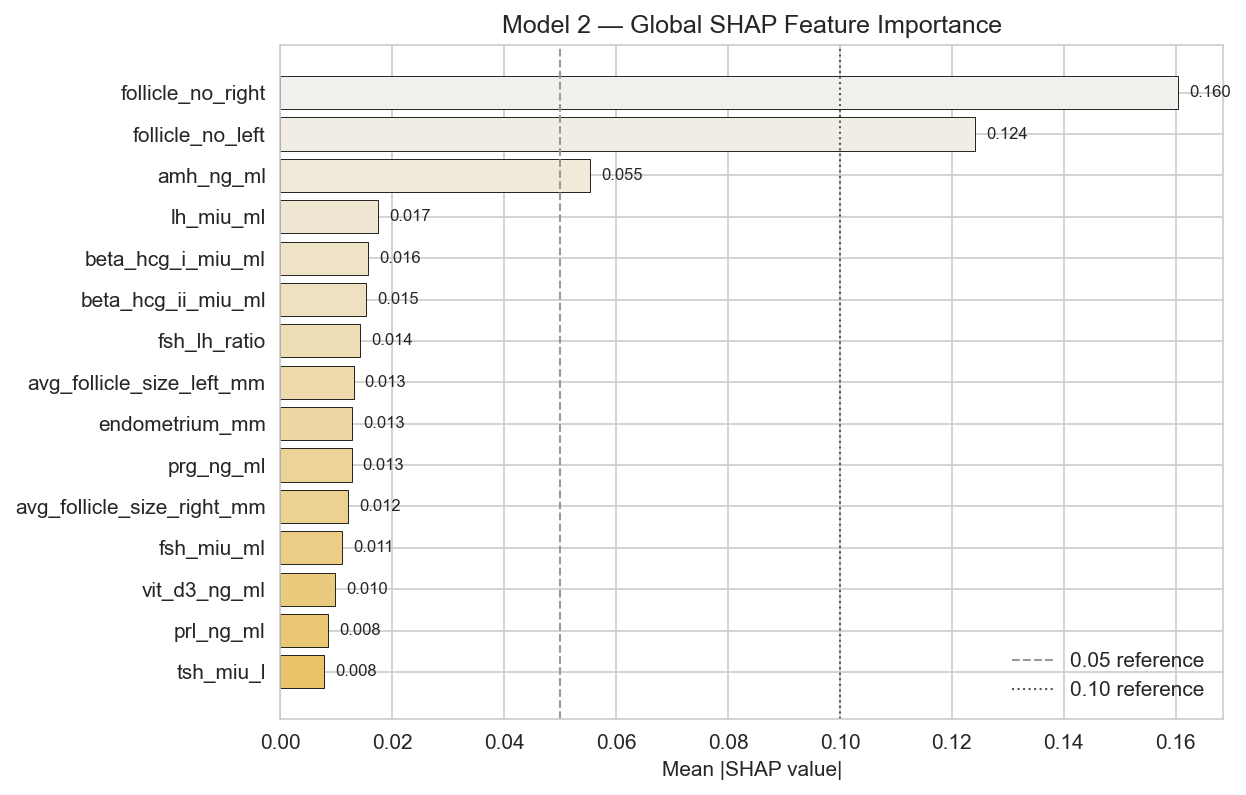

In [170]:
# Plotting the global SHAP bar chart is showing the average absolute contribution of each Model 2 feature.
fig, ax = plt.subplots(figsize=(8.4, 5.4))
plot_df = global_bar_m2.sort_values('mean_abs_shap', ascending=True)
colors = sns.light_palette(COLORS['model2'], n_colors=len(plot_df), reverse=True)
bars = ax.barh(plot_df['feature'], plot_df['mean_abs_shap'], color=colors, edgecolor='black', linewidth=0.4)
ax.axvline(0.05, color='#999999', linestyle='--', linewidth=1, label='0.05 reference')
ax.axvline(0.10, color='#555555', linestyle=':', linewidth=1, label='0.10 reference')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Model 2 — Global SHAP Feature Importance')
for bar, value in zip(bars, plot_df['mean_abs_shap']):
    ax.text(value + 0.002, bar.get_y() + bar.get_height() / 2, f'{value:.3f}', va='center', fontsize=8)
ax.legend(loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '14_m2_shap_bar_global.png', bbox_inches='tight')
plt.show()


### Global Bar Chart Insight

This chart is showing the features with the strongest average effect on the prediction. Features at the top of the chart are the ones the model is using most often. This matters because these are the features you would mention first when explaining how the model works.


In [171]:
# Printing the beeswarm support table is showing the average SHAP direction for high and low feature values before plotting.
beeswarm_summary_m2 = []
for feature in MODEL2_FEATURES:
    values = m2_test_df[feature].values
    shap_col = sv_m2[:, MODEL2_FEATURES.index(feature)]
    median_value = float(np.nanmedian(values))
    high_mask = values >= median_value
    low_mask = values < median_value
    beeswarm_summary_m2.append({
        'feature': feature,
        'median_value': median_value,
        'mean_shap_high_values': float(np.nanmean(shap_col[high_mask])) if high_mask.any() else np.nan,
        'mean_shap_low_values': float(np.nanmean(shap_col[low_mask])) if low_mask.any() else np.nan,
    })
beeswarm_summary_m2 = pd.DataFrame(beeswarm_summary_m2).sort_values('feature')
print(beeswarm_summary_m2.round(4).to_string(index=False))


                   feature  median_value  mean_shap_high_values  mean_shap_low_values
                 amh_ng_ml        0.0524                 0.0281               -0.0520
 avg_follicle_size_left_mm        0.6250                 0.0054               -0.0184
avg_follicle_size_right_mm        0.6667                 0.0044               -0.0106
         beta_hcg_i_miu_ml        0.0026                 0.0128               -0.0131
        beta_hcg_ii_miu_ml        0.0000                -0.0004               -0.0092
            endometrium_mm        0.3871                 0.0072               -0.0152
          follicle_no_left        0.2727                 0.0528               -0.1340
         follicle_no_right        0.3500                 0.0951               -0.1847
              fsh_lh_ratio        0.0014                -0.0102                0.0018
                fsh_miu_ml        0.0009                -0.0098                0.0078
                 lh_miu_ml        0.1500              

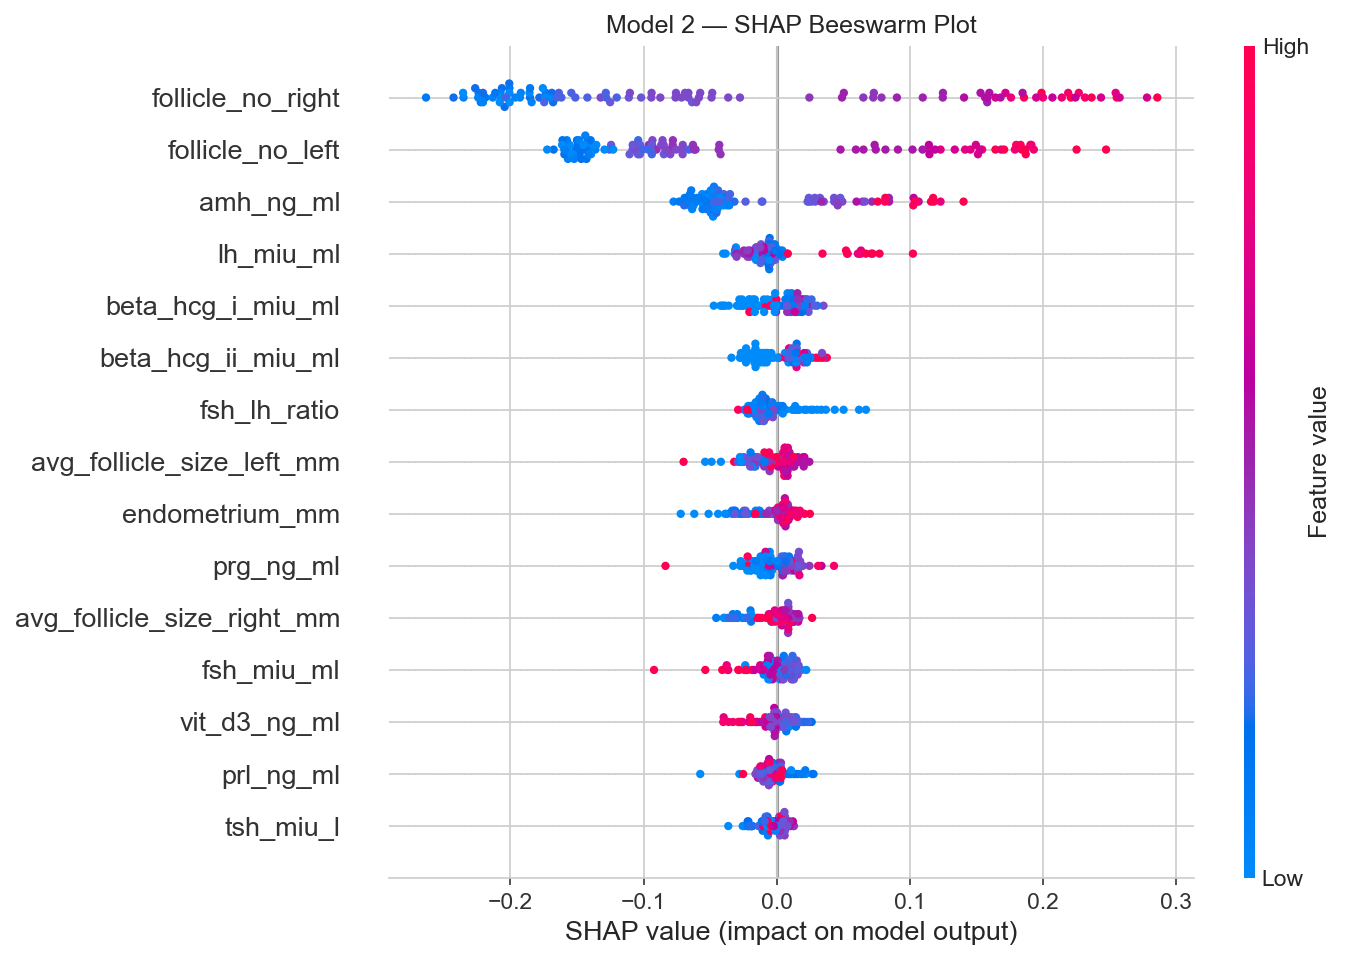

In [172]:
# Plotting the beeswarm view is showing both SHAP direction and patient-level spread for Model 2.
shap.summary_plot(sv_m2, m2_test_df, feature_names=MODEL2_FEATURES, show=False, plot_size=(9.5, 6.5))
plt.title('Model 2 — SHAP Beeswarm Plot')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '15_m2_shap_beeswarm.png', bbox_inches='tight')
plt.show()


### Reading the Beeswarm Plot — Model 2

Each dot is one patient. The horizontal position is showing how much that feature pushed the prediction toward PCOS on the right or away from PCOS on the left. The colour is showing whether that patient's feature value was high or low. When red dots sit more on the right and blue dots sit more on the left, it means higher values of that feature are usually increasing the model's PCOS risk estimate.


In [173]:
# Printing SHAP summary statistics is showing the exact matrix summary used before the heatmap.
shap_stats_m2 = pd.DataFrame({
    'feature': MODEL2_FEATURES,
    'mean': sv_m2.mean(axis=0),
    'std': sv_m2.std(axis=0),
    'min': sv_m2.min(axis=0),
    'max': sv_m2.max(axis=0),
})
print(shap_stats_m2.round(4).to_string(index=False))


                   feature    mean    std     min    max
                 amh_ng_ml -0.0116 0.0590 -0.0775 0.1404
                fsh_miu_ml -0.0011 0.0163 -0.0921 0.0223
                 lh_miu_ml -0.0015 0.0264 -0.0401 0.1024
              fsh_lh_ratio -0.0042 0.0174 -0.0289 0.0671
                 tsh_miu_l -0.0036 0.0094 -0.0363 0.0130
                 prl_ng_ml -0.0030 0.0110 -0.0574 0.0277
              vit_d3_ng_ml -0.0013 0.0133 -0.0401 0.0263
                 prg_ng_ml -0.0024 0.0162 -0.0835 0.0431
         beta_hcg_i_miu_ml -0.0000 0.0187 -0.0472 0.0352
        beta_hcg_ii_miu_ml -0.0005 0.0172 -0.0339 0.0377
          follicle_no_left -0.0329 0.1267 -0.1724 0.2475
         follicle_no_right -0.0358 0.1691 -0.2634 0.2860
 avg_follicle_size_left_mm -0.0031 0.0167 -0.0699 0.0246
avg_follicle_size_right_mm -0.0022 0.0157 -0.0454 0.0267
            endometrium_mm -0.0034 0.0177 -0.0721 0.0250


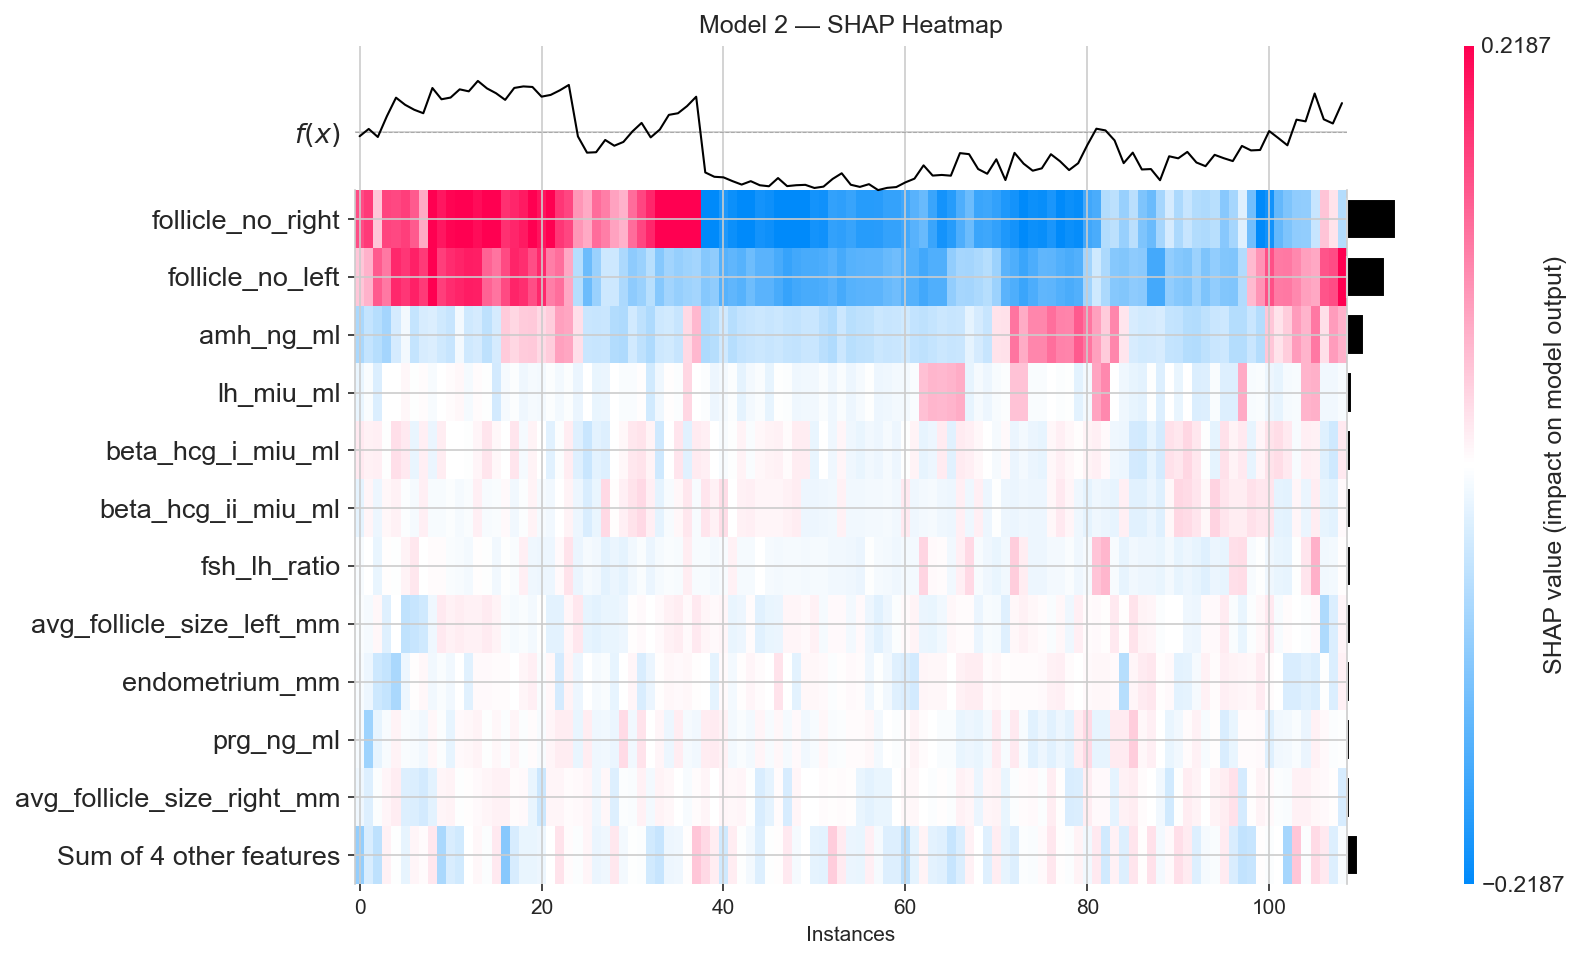

In [174]:
# Plotting the SHAP heatmap is showing whether groups of patients share similar explanation patterns.
shap.plots.heatmap(explanation_m2, show=False, max_display=min(12, len(MODEL2_FEATURES)))
plt.gcf().set_size_inches(10, 6.5)
plt.title('Model 2 — SHAP Heatmap')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '16_m2_shap_heatmap.png', bbox_inches='tight')
plt.show()


### Heatmap Insight

This heatmap is showing whether some patients share similar explanation patterns. If blocks of colour appear together, that suggests the model is seeing clusters of patients with similar feature-driven risk patterns.


### Local SHAP Explanation — Model 2

This section is moving from the population view to the patient view. Three cases are being checked: a true positive, a false negative, and a false positive. This is showing why the final stack got a patient right, why it missed a case, and why it raised a false alarm.


In [175]:
# Selecting one true positive, one false negative, and one false positive is preparing the local explanation cases.
selected_cases_m2 = select_case_indices(y2_test, y_m2_pred, y_m2_proba)
print('Case counts:')
print(f"  TP count: {selected_cases_m2['tp_count']}")
print(f"  FN count: {selected_cases_m2['fn_count']}")
print(f"  FP count: {selected_cases_m2['fp_count']}")
print()
print('Selected indices:')
print(selected_cases_m2)


Case counts:
  TP count: 28
  FN count: 8
  FP count: 6

Selected indices:
{'tp_idx': 101, 'fn_idx': 6, 'fp_idx': 94, 'tp_count': 28, 'fn_count': 8, 'fp_count': 6}


In [176]:
# Printing the selected patient feature values is showing the raw profile behind each local explanation.
patient_cases_m2 = m2_test_df.copy()
for case_label in ['tp', 'fn', 'fp']:
    idx = selected_cases_m2[f'{case_label}_idx']
    print(case_label.upper(), 'patient values')
    print(patient_cases_m2.iloc[idx].to_string())
    print(f"Predicted probability: {y_m2_proba[idx]:.4f}")
    print(f"Actual label: {int(y2_test[idx])} | Predicted label: {int(y_m2_pred[idx])}")
    print('-' * 60)


TP patient values
amh_ng_ml                     0.004097
fsh_miu_ml                    0.001027
lh_miu_ml                     0.130850
fsh_lh_ratio                  0.001851
tsh_miu_l                     0.012041
prl_ng_ml                     0.192923
vit_d3_ng_ml                  0.002084
prg_ng_ml                     0.016354
beta_hcg_i_miu_ml             0.000369
beta_hcg_ii_miu_ml            0.000738
follicle_no_left              0.545455
follicle_no_right             0.550000
avg_follicle_size_left_mm     0.791667
avg_follicle_size_right_mm    0.791667
endometrium_mm                0.361290
Predicted probability: 0.9488
Actual label: 1 | Predicted label: 1
------------------------------------------------------------
FN patient values
amh_ng_ml                     0.001517
fsh_miu_ml                    0.000606
lh_miu_ml                     0.104243
fsh_lh_ratio                  0.001361
tsh_miu_l                     0.033344
prl_ng_ml                     0.308335
vit_d3_ng_ml     

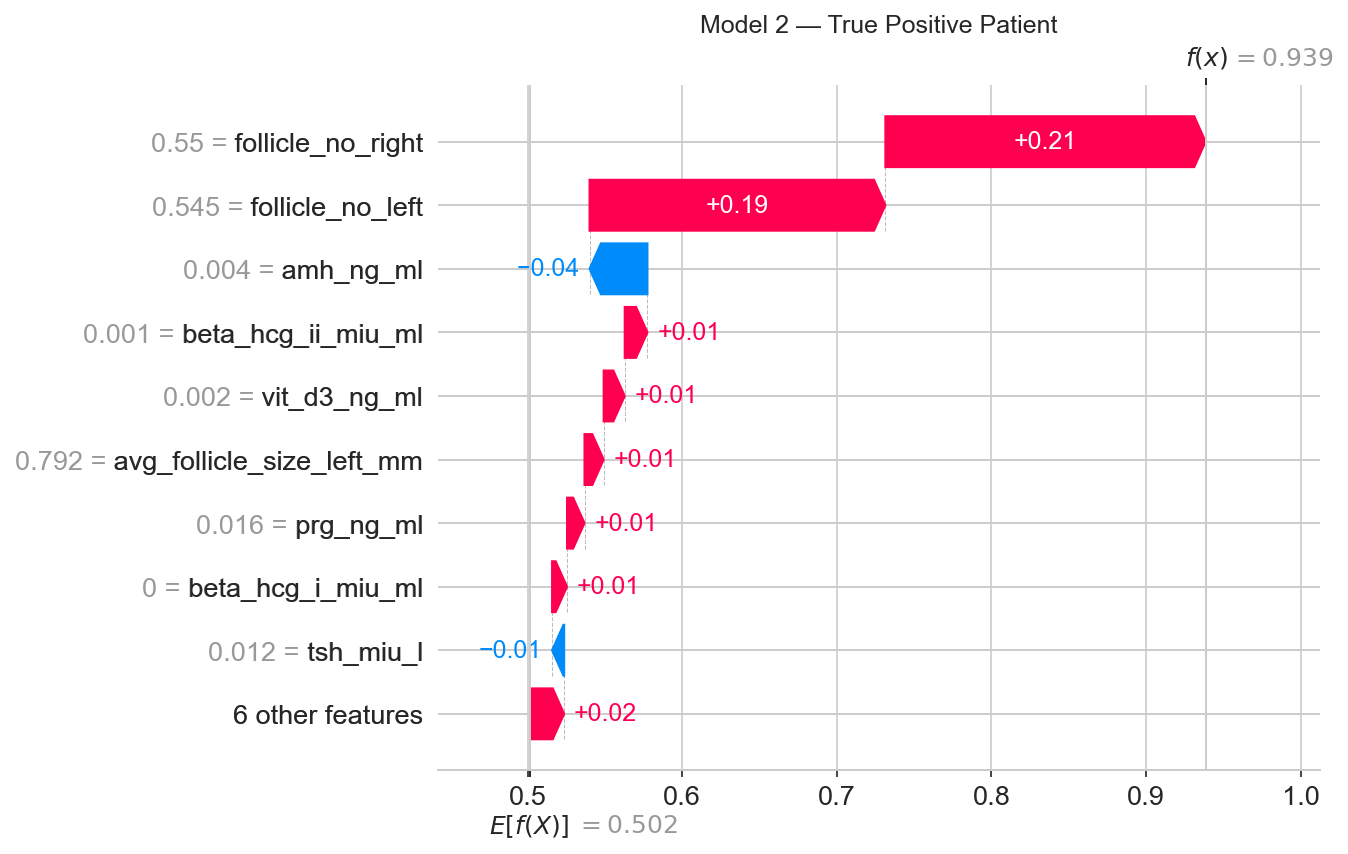

In [177]:
# Plotting the true positive waterfall is showing which features pushed this case up or down.
tp_idx_m2 = selected_cases_m2['tp_idx']
tp_explanation_m2 = shap.Explanation(
    values=sv_m2[tp_idx_m2],
    base_values=expected_value_m2,
    data=X2_test[tp_idx_m2],
    feature_names=MODEL2_FEATURES,
)
shap.plots.waterfall(tp_explanation_m2, show=False)
plt.gcf().set_size_inches(9, 5.8)
plt.title('Model 2 — True Positive Patient')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '17_m2_shap_waterfall_true_positive.png', bbox_inches='tight')
plt.show()


### True Positive Waterfall Insight

This waterfall is showing how the final score moved from the base value to the patient's final prediction. Features pushing to the right are raising risk, and features pushing to the left are lowering risk. This matters because it shows the exact feature mix behind a correct call, a missed case, or a false alarm.


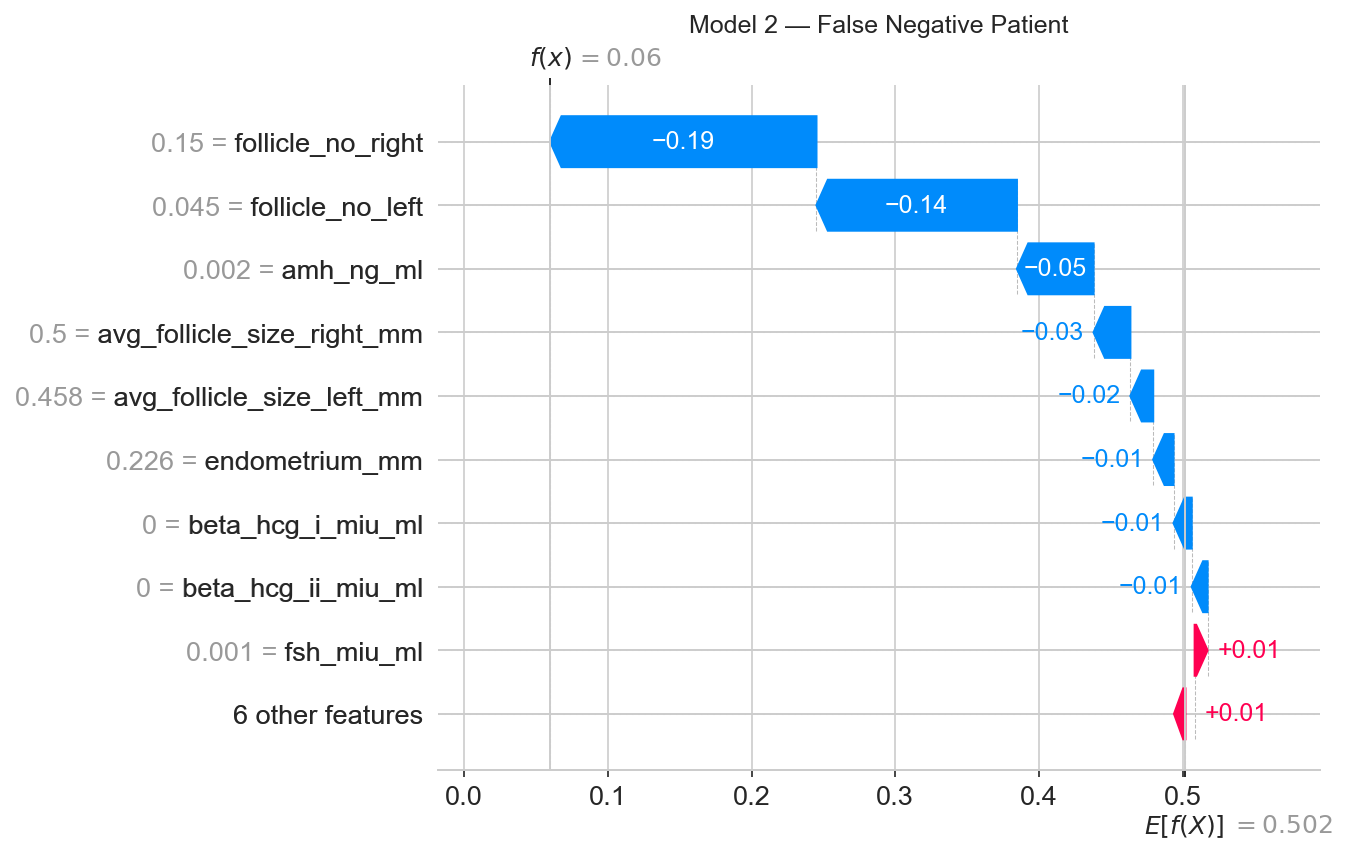

In [178]:
# Plotting the false negative waterfall is showing which features pushed this case up or down.
fn_idx_m2 = selected_cases_m2['fn_idx']
fn_explanation_m2 = shap.Explanation(
    values=sv_m2[fn_idx_m2],
    base_values=expected_value_m2,
    data=X2_test[fn_idx_m2],
    feature_names=MODEL2_FEATURES,
)
shap.plots.waterfall(fn_explanation_m2, show=False)
plt.gcf().set_size_inches(9, 5.8)
plt.title('Model 2 — False Negative Patient')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '18_m2_shap_waterfall_false_negative.png', bbox_inches='tight')
plt.show()


### False Negative Waterfall Insight

This waterfall is showing how the final score moved from the base value to the patient's final prediction. Features pushing to the right are raising risk, and features pushing to the left are lowering risk. This matters because it shows the exact feature mix behind a correct call, a missed case, or a false alarm.


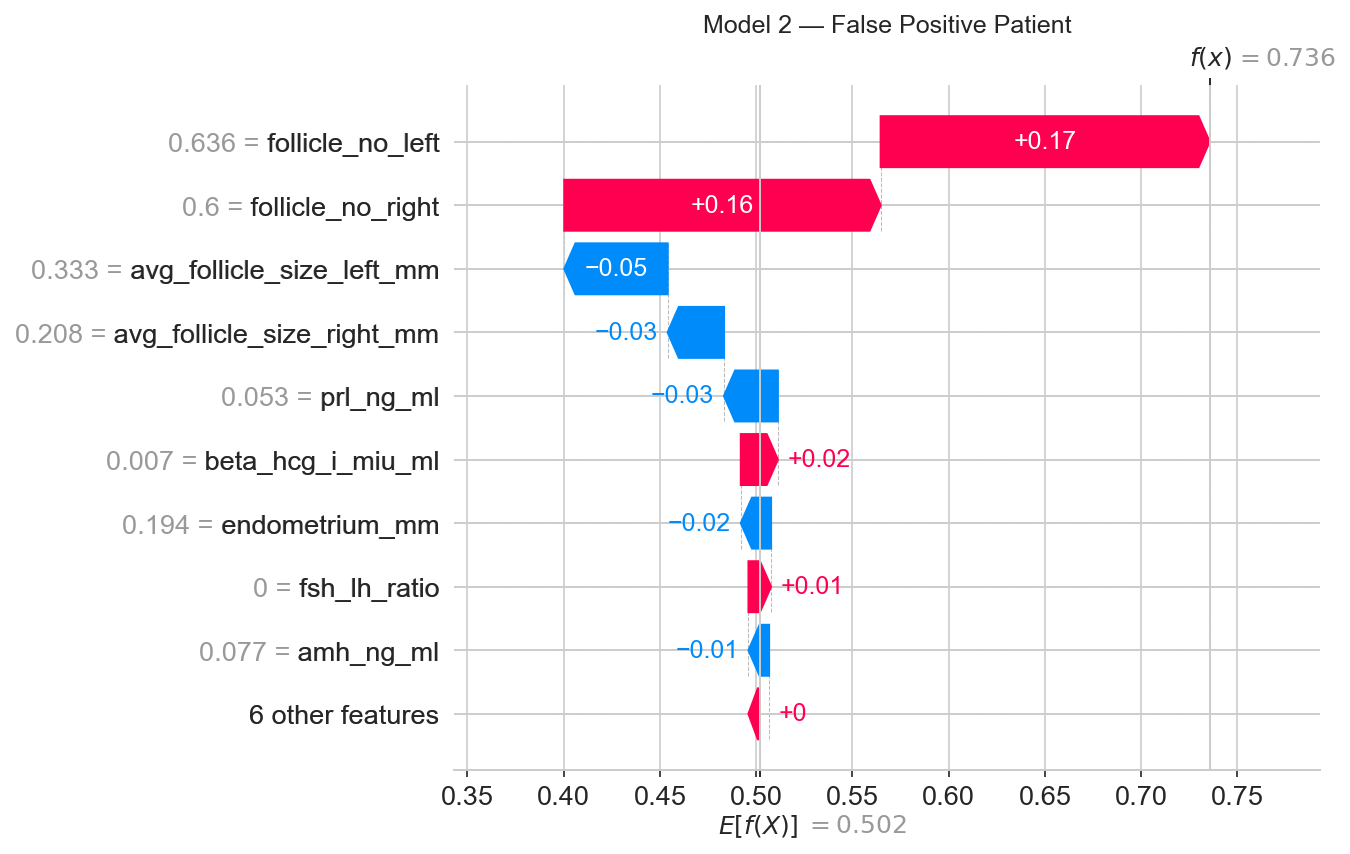

In [179]:
# Plotting the false positive waterfall is showing which features pushed this case up or down.
fp_idx_m2 = selected_cases_m2['fp_idx']
fp_explanation_m2 = shap.Explanation(
    values=sv_m2[fp_idx_m2],
    base_values=expected_value_m2,
    data=X2_test[fp_idx_m2],
    feature_names=MODEL2_FEATURES,
)
shap.plots.waterfall(fp_explanation_m2, show=False)
plt.gcf().set_size_inches(9, 5.8)
plt.title('Model 2 — False Positive Patient')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '19_m2_shap_waterfall_false_positive.png', bbox_inches='tight')
plt.show()


### False Positive Waterfall Insight

This waterfall is showing how the final score moved from the base value to the patient's final prediction. Features pushing to the right are raising risk, and features pushing to the left are lowering risk. This matters because it shows the exact feature mix behind a correct call, a missed case, or a false alarm.


### SHAP Dependence Plots — Model 2

Dependence plots are showing how the value of a feature is relating to its SHAP contribution across patients. This helps answer whether the effect is roughly linear, threshold-based, or more mixed.


In [180]:
# Printing the top three SHAP features is selecting the features used for the dependence plots.
top3_m2 = shap_rank_m2.head(3)['feature'].tolist()
top3_table_m2 = shap_rank_m2.head(3)[['rank', 'feature', 'mean_abs_shap']]
print(top3_table_m2.to_string(index=False))


 rank           feature  mean_abs_shap
    1 follicle_no_right       0.160465
    2  follicle_no_left       0.124141
    3         amh_ng_ml       0.055336


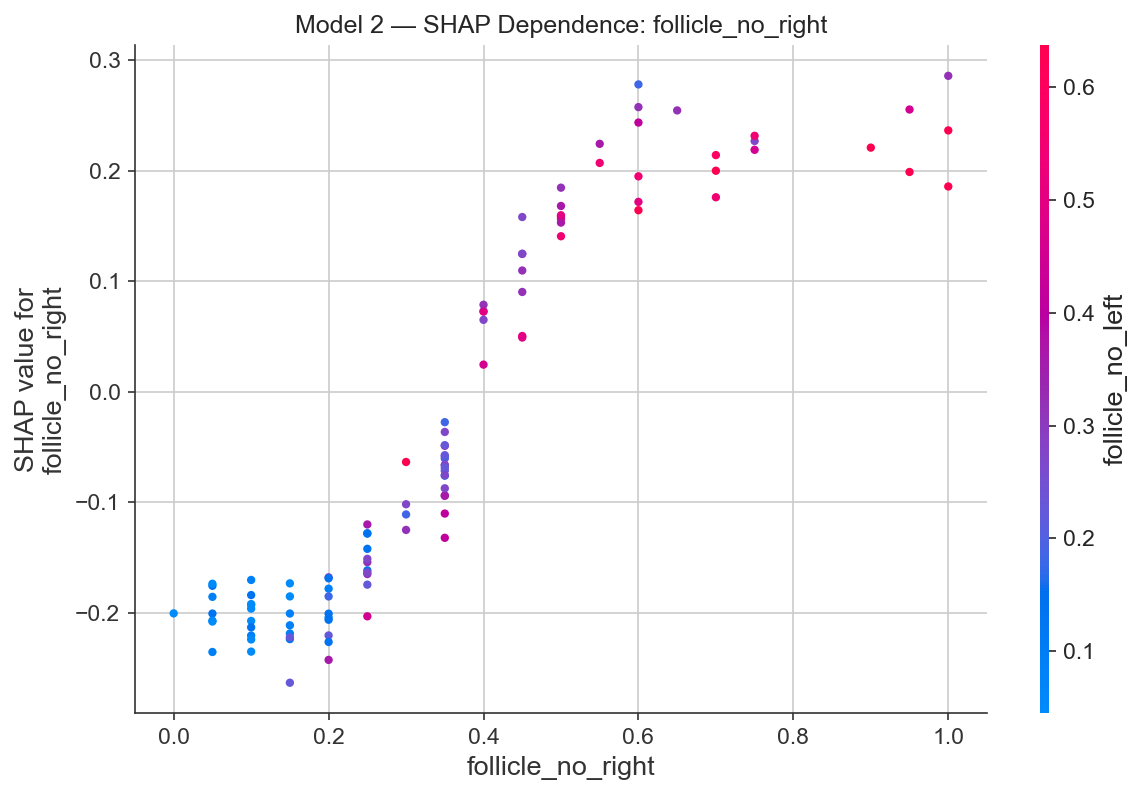

In [181]:
# Plotting dependence feature 1 is showing how one top feature changes its SHAP contribution across patients.
feature_m2_1 = top3_m2[0]
shap.dependence_plot(feature_m2_1, sv_m2, m2_test_df, feature_names=MODEL2_FEATURES, interaction_index='auto', show=False)
plt.gcf().set_size_inches(8.2, 5.4)
plt.title('Model 2 — SHAP Dependence: ' + feature_m2_1)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '20_m2_shap_dependence_feature1.png', bbox_inches='tight')
plt.show()


### Dependence Plot Insight

This dependence plot is showing how the feature value and the SHAP effect move together. A smooth upward or downward pattern suggests a more monotonic effect, while a scattered pattern suggests a more mixed or threshold-like effect.


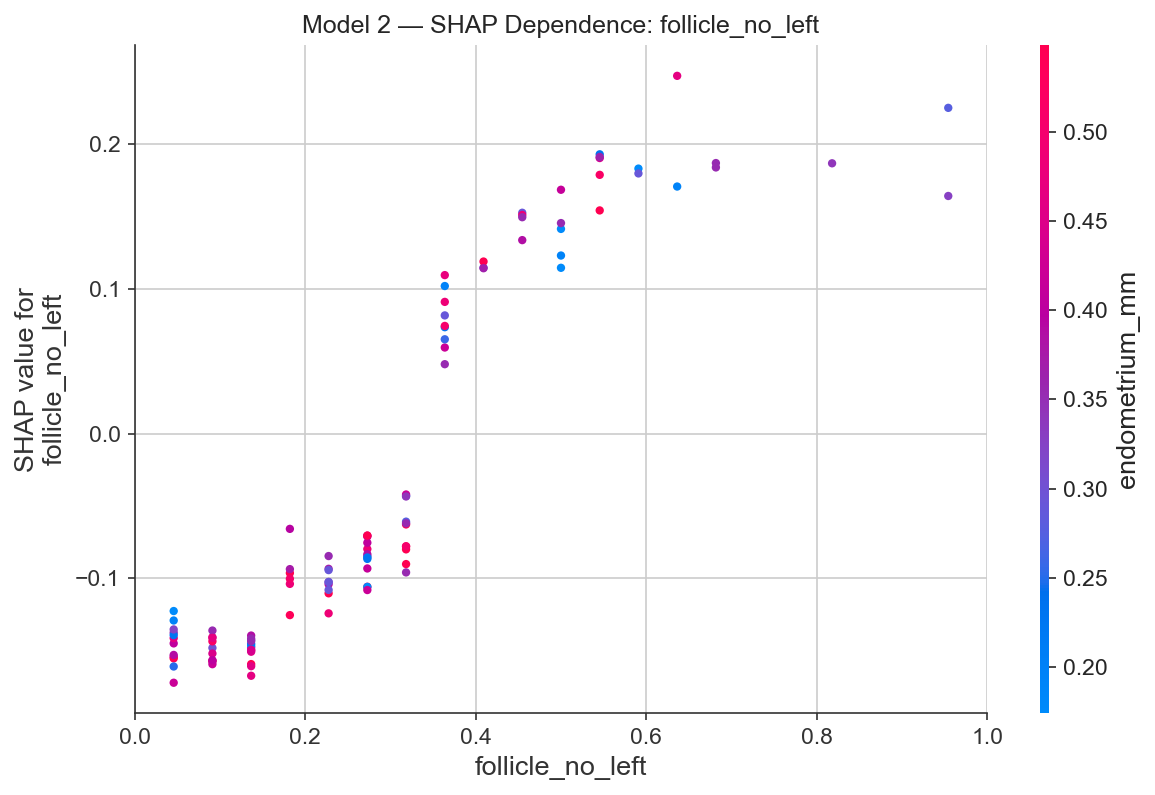

In [182]:
# Plotting dependence feature 2 is showing how one top feature changes its SHAP contribution across patients.
feature_m2_2 = top3_m2[1]
shap.dependence_plot(feature_m2_2, sv_m2, m2_test_df, feature_names=MODEL2_FEATURES, interaction_index='auto', show=False)
plt.gcf().set_size_inches(8.2, 5.4)
plt.title('Model 2 — SHAP Dependence: ' + feature_m2_2)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '21_m2_shap_dependence_feature2.png', bbox_inches='tight')
plt.show()


### Dependence Plot Insight

This dependence plot is showing how the feature value and the SHAP effect move together. A smooth upward or downward pattern suggests a more monotonic effect, while a scattered pattern suggests a more mixed or threshold-like effect.


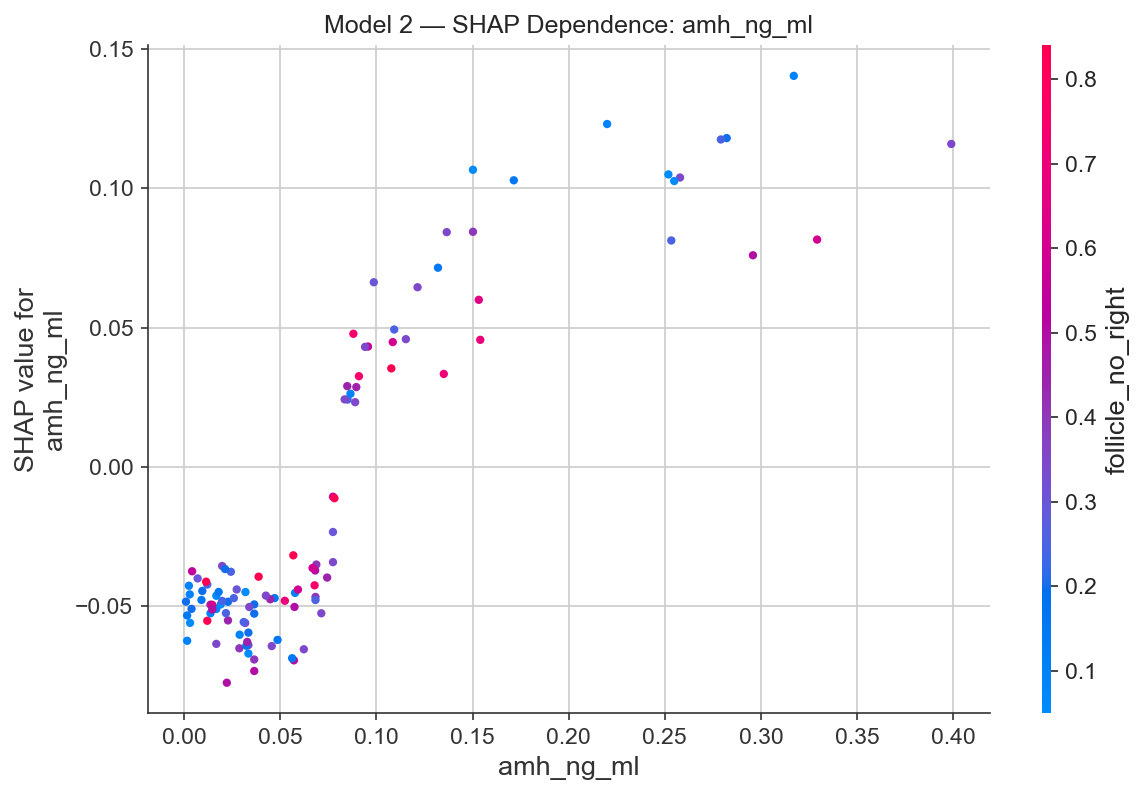

In [183]:
# Plotting dependence feature 3 is showing how one top feature changes its SHAP contribution across patients.
feature_m2_3 = top3_m2[2]
shap.dependence_plot(feature_m2_3, sv_m2, m2_test_df, feature_names=MODEL2_FEATURES, interaction_index='auto', show=False)
plt.gcf().set_size_inches(8.2, 5.4)
plt.title('Model 2 — SHAP Dependence: ' + feature_m2_3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '22_m2_shap_dependence_feature3.png', bbox_inches='tight')
plt.show()


### Dependence Plot Insight

This dependence plot is showing how the feature value and the SHAP effect move together. A smooth upward or downward pattern suggests a more monotonic effect, while a scattered pattern suggests a more mixed or threshold-like effect.


In [184]:
# Printing the interaction support table is showing the exact grouped data used before the interaction plot.
idx_a_m2 = MODEL2_FEATURES.index('amh_ng_ml')
idx_b_m2 = MODEL2_FEATURES.index('fsh_lh_ratio')
interaction_df_m2 = pd.DataFrame({
    'feature_a_value': X2_test[:, idx_a_m2],
    'feature_a_shap': sv_m2[:, idx_a_m2],
    'feature_b_value': X2_test[:, idx_b_m2],
})
if 'fsh_lh_ratio' == 'cycle_regularity_binary':
    interaction_df_m2['feature_b_group'] = interaction_df_m2['feature_b_value'].map({0: 'Irregular', 1: 'Regular'}).fillna('Unknown')
else:
    interaction_df_m2['feature_b_group'] = pd.qcut(
        interaction_df_m2['feature_b_value'],
        q=2,
        labels=['Lower', 'Higher'],
        duplicates='drop',
    )
interaction_groups_m2 = interaction_df_m2.groupby('feature_b_group')[['feature_a_value', 'feature_a_shap']].describe().round(3)
print(interaction_groups_m2.to_string())


                feature_a_value                                                  feature_a_shap                                                 
                          count   mean    std    min    25%    50%    75%    max          count   mean    std    min    25%    50%    75%    max
feature_b_group                                                                                                                                 
Lower                      55.0  0.087  0.096  0.002  0.021  0.049  0.102  0.399           55.0 -0.003  0.061 -0.077 -0.049 -0.041  0.044  0.140
Higher                     54.0  0.067  0.064  0.001  0.023  0.054  0.078  0.279           54.0 -0.020  0.057 -0.073 -0.054 -0.046 -0.016  0.118


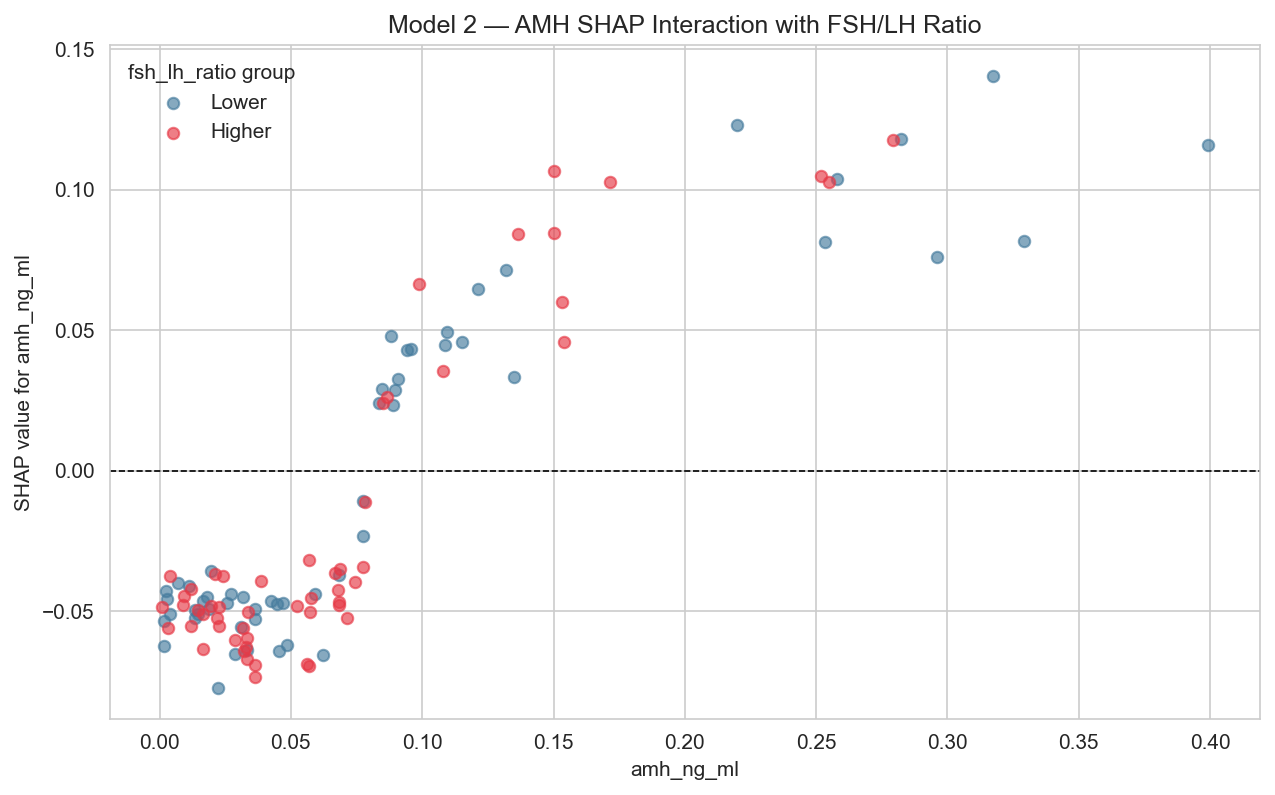

In [185]:
# Plotting the main interaction view is checking whether feature A is acting differently at different levels of feature B.
interaction_plot_df_m2 = interaction_df_m2.copy()
fig, ax = plt.subplots(figsize=(8.6, 5.4))
if 'fsh_lh_ratio' == 'cycle_regularity_binary':
    palette = {'Irregular': COLORS['shap_pos'], 'Regular': COLORS['shap_neg'], 'Unknown': COLORS['neutral']}
else:
    palette = {'Lower': COLORS['shap_neg'], 'Higher': COLORS['shap_pos']}
for group_name, group_df in interaction_plot_df_m2.groupby('feature_b_group'):
    ax.scatter(
        group_df['feature_a_value'],
        group_df['feature_a_shap'],
        s=30,
        alpha=0.65,
        color=palette[str(group_name)],
        label=str(group_name),
    )
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('amh_ng_ml')
ax.set_ylabel('SHAP value for amh_ng_ml')
ax.set_title('Model 2 — AMH SHAP Interaction with FSH/LH Ratio')
ax.legend(title='fsh_lh_ratio group', frameon=False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '23_m2_shap_interaction_amh_fsh.png', bbox_inches='tight')
plt.show()


### Interaction Plot Insight

This interaction plot is checking whether `amh_ng_ml` becomes more or less important when `fsh_lh_ratio` changes. This matters because PCOS risk often comes from combined feature patterns rather than from isolated features.


In [186]:
# Printing the meta-learner coefficient table is showing how much the final LR meta-model trusted each base learner.
meta_coefs_m2 = final_bundle_m2['meta_model'].coef_[0]
base_names_m2 = ['Logistic Regression', 'Random Forest', 'XGBoost']
meta_weight_df_m2 = pd.DataFrame({
    'base_learner': base_names_m2,
    'coefficient': meta_coefs_m2,
    'abs_weight': np.abs(meta_coefs_m2),
}).sort_values('abs_weight', ascending=False).reset_index(drop=True)
print(meta_weight_df_m2.to_string(index=False))


       base_learner  coefficient  abs_weight
      Random Forest     4.670975    4.670975
            XGBoost     1.739828    1.739828
Logistic Regression     0.384896    0.384896


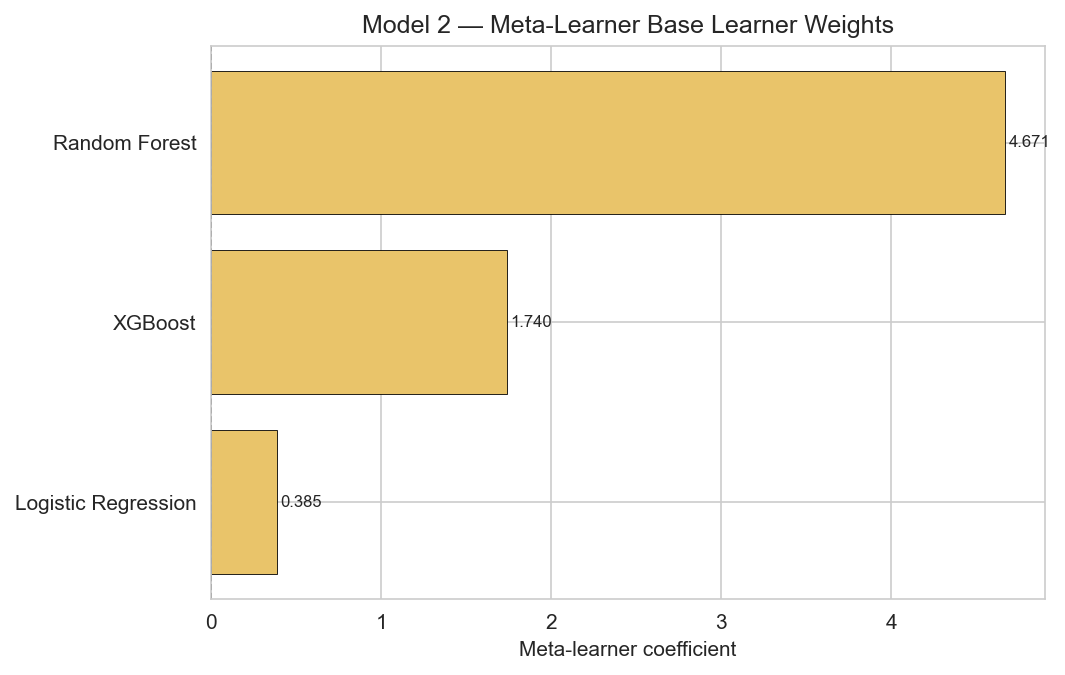

In [187]:
# Plotting the meta-learner weight chart is showing which base learner the final stack trusted most.
fig, ax = plt.subplots(figsize=(7.2, 4.6))
meta_plot_df_m2 = meta_weight_df_m2.sort_values('coefficient')
colors_m2 = [COLORS['model2'] if val >= 0 else COLORS['shap_neg'] for val in meta_plot_df_m2['coefficient']]
bars = ax.barh(meta_plot_df_m2['base_learner'], meta_plot_df_m2['coefficient'], color=colors_m2, edgecolor='black', linewidth=0.4)
ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Meta-learner coefficient')
ax.set_title('Model 2 — Meta-Learner Base Learner Weights')
for bar, value in zip(bars, meta_plot_df_m2['coefficient']):
    ax.text(value + (0.02 if value >= 0 else -0.02), bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center', ha='left' if value >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'model2' / '24_m2_meta_base_learner_weights.png', bbox_inches='tight')
plt.show()


### Meta-Learner Weight Insight

This chart is showing how strongly the final stack is weighting each base learner. A larger absolute coefficient means the meta-learner is trusting that base learner more when it forms the final probability.


In [188]:
# Running a small Kernel SHAP fidelity check is checking whether the RF-based SHAP story broadly matches the full final stack on a small subset.
background_idx_m2 = stratified_take(y2_train, 40, seed=RANDOM_STATE)
explain_idx_m2 = stratified_take(y2_test, 30, seed=RANDOM_STATE + 1)
background_m2 = X2_train[background_idx_m2]
explain_subset_m2 = X2_test[explain_idx_m2]
kernel_explainer_m2 = shap.KernelExplainer(lambda data: stack_predict_proba(final_bundle_m2, np.asarray(data))[1], background_m2)
kernel_values_raw_m2 = kernel_explainer_m2.shap_values(explain_subset_m2, nsamples=100)
kernel_sv_m2 = extract_positive_shap(kernel_values_raw_m2)
kernel_rank_m2 = pd.DataFrame({
    'feature': MODEL2_FEATURES,
    'kernel_mean_abs_shap': np.abs(kernel_sv_m2).mean(axis=0),
}).sort_values('kernel_mean_abs_shap', ascending=False).reset_index(drop=True)
fidelity_top_m2 = kernel_rank_m2.head(5).copy()
rf_top_m2 = shap_rank_m2.head(5)[['feature', 'mean_abs_shap']].copy()
overlap_m2 = sorted(set(fidelity_top_m2['feature']) & set(rf_top_m2['feature']))
print('Kernel SHAP top five on the small stack subset:')
print(fidelity_top_m2.to_string(index=False))
print()
print('RF TreeSHAP top five on the full test set:')
print(rf_top_m2.to_string(index=False))
print()
print('Top-five overlap:')
print(overlap_m2)


  0%|          | 0/30 [00:00<?, ?it/s]

Kernel SHAP top five on the small stack subset:
          feature  kernel_mean_abs_shap
follicle_no_right              0.199816
 follicle_no_left              0.106162
        amh_ng_ml              0.047494
     fsh_lh_ratio              0.015897
        tsh_miu_l              0.013810

RF TreeSHAP top five on the full test set:
          feature  mean_abs_shap
follicle_no_right       0.160465
 follicle_no_left       0.124141
        amh_ng_ml       0.055336
        lh_miu_ml       0.017461
beta_hcg_i_miu_ml       0.015739

Top-five overlap:
['amh_ng_ml', 'follicle_no_left', 'follicle_no_right']


### Full-Stack Fidelity Check

This check is not replacing the main TreeSHAP analysis. It is only checking whether the top features from the fast Random Forest explanation broadly agree with the full final stack on a small subset. If the overlap is reasonable, the main SHAP story is easier to defend.


In [189]:
# Writing the clinical summary is turning the main SHAP findings into a short explanation that can be used in the thesis discussion.
top_features_m2 = ', '.join([f"`{name}`" for name in shap_rank_m2.head(5)['feature'].tolist()])
if 'm2' == 'm2':
    marker_hits = [name for name in ['amh_ng_ml', 'fsh_lh_ratio', 'follicle_no_left', 'follicle_no_right'] if name in shap_rank_m2.head(5)['feature'].tolist()]
    marker_text = ', '.join([f"`{name}`" for name in marker_hits]) if marker_hits else 'none of the expected marker group'
    extra_text = f" Literature-linked markers appearing in the top five are: {marker_text}."
else:
    extra_text = ''
render_markdown(
    '### Model 2 Clinical Summary\n'
    f'**What the top features are:** {top_features_m2}.\n'
    f'**What the local cases show:** The selected true positive, false negative, and false positive cases are showing how the model gets a case right, misses a case, or raises a false alarm.\n'
    f'**What the interaction shows:** The interaction plot is showing whether two clinically related features are making each other stronger or weaker.\n'
    f'**Why this matters:** This gives a feature-level explanation of how model 2 is making decisions.{extra_text}\n'
    f'**Simple summary:** The SHAP results are showing the main features that the final model 2 is relying on.'
)


### Model 2 Clinical Summary
**What the top features are:** `follicle_no_right`, `follicle_no_left`, `amh_ng_ml`, `lh_miu_ml`, `beta_hcg_i_miu_ml`.
**What the local cases show:** The selected true positive, false negative, and false positive cases are showing how the model gets a case right, misses a case, or raises a false alarm.
**What the interaction shows:** The interaction plot is showing whether two clinically related features are making each other stronger or weaker.
**Why this matters:** This gives a feature-level explanation of how model 2 is making decisions. Literature-linked markers appearing in the top five are: `amh_ng_ml`, `follicle_no_left`, `follicle_no_right`.
**Simple summary:** The SHAP results are showing the main features that the final model 2 is relying on.

## Section 5 — Survey External Validation

This section is testing how the final non-invasive optimized model behaves on a different data collection setting. The survey dataset was not used for training. It is self-reported, and some Model 1 features were missing there and had to be placeholder-filled in Notebook 07. This means the validation is useful, but it is still approximate and should be read carefully.


In [190]:
# Printing the survey dataset profile is showing what kind of external-style validation set is being used.
print(f'Survey validation set shape : {survey.shape}')
print(f'Feature count               : {len(MODEL1_FEATURES)}')
print()
print('Class distribution in survey validation set:')
print(survey[TARGET].value_counts().to_string())
print()
print(survey[TARGET].value_counts(normalize=True).mul(100).round(2).to_string())
print()
print('Feature alignment status from Notebook 07:')
print('Direct survey features  : age_yrs, bmi, weight_gain_y_n, hair_growth_y_n,')
print('                          skin_darkening_y_n, hair_loss_y_n, pimples_y_n,')
print('                          fast_food_y_n, regular_exercise_y_n,')
print('                          cycle_regularity_binary, cycle_length_days')
print('Imputed with clinical')
print('training medians        : systolic_bp_mmhg, diastolic_bp_mmhg,')
print('                          waist_hip_ratio, rbs_mg_dl')
print('Derived features        : symptom_burden, bmi_category, bp_elevated_flag, lifestyle_risk')


Survey validation set shape : (464, 20)
Feature count               : 19

Class distribution in survey validation set:
pcos_y_n
0    363
1    101

pcos_y_n
0    78.23
1    21.77

Feature alignment status from Notebook 07:
Direct survey features  : age_yrs, bmi, weight_gain_y_n, hair_growth_y_n,
                          skin_darkening_y_n, hair_loss_y_n, pimples_y_n,
                          fast_food_y_n, regular_exercise_y_n,
                          cycle_regularity_binary, cycle_length_days
Imputed with clinical
training medians        : systolic_bp_mmhg, diastolic_bp_mmhg,
                          waist_hip_ratio, rbs_mg_dl
Derived features        : symptom_burden, bmi_category, bp_elevated_flag, lifestyle_risk


In [191]:
# Printing the class-distribution comparison table is preparing the data behind the survey balance plot.
survey_balance_df = pd.DataFrame({
    'dataset': ['Survey', 'Survey', 'Clinical Test', 'Clinical Test'],
    'label': ['No PCOS', 'PCOS', 'No PCOS', 'PCOS'],
    'count': [
        int((y_survey == 0).sum()),
        int((y_survey == 1).sum()),
        int((y1_test == 0).sum()),
        int((y1_test == 1).sum()),
    ]
})
print(survey_balance_df.to_string(index=False))


      dataset   label  count
       Survey No PCOS    363
       Survey    PCOS    101
Clinical Test No PCOS     73
Clinical Test    PCOS     36


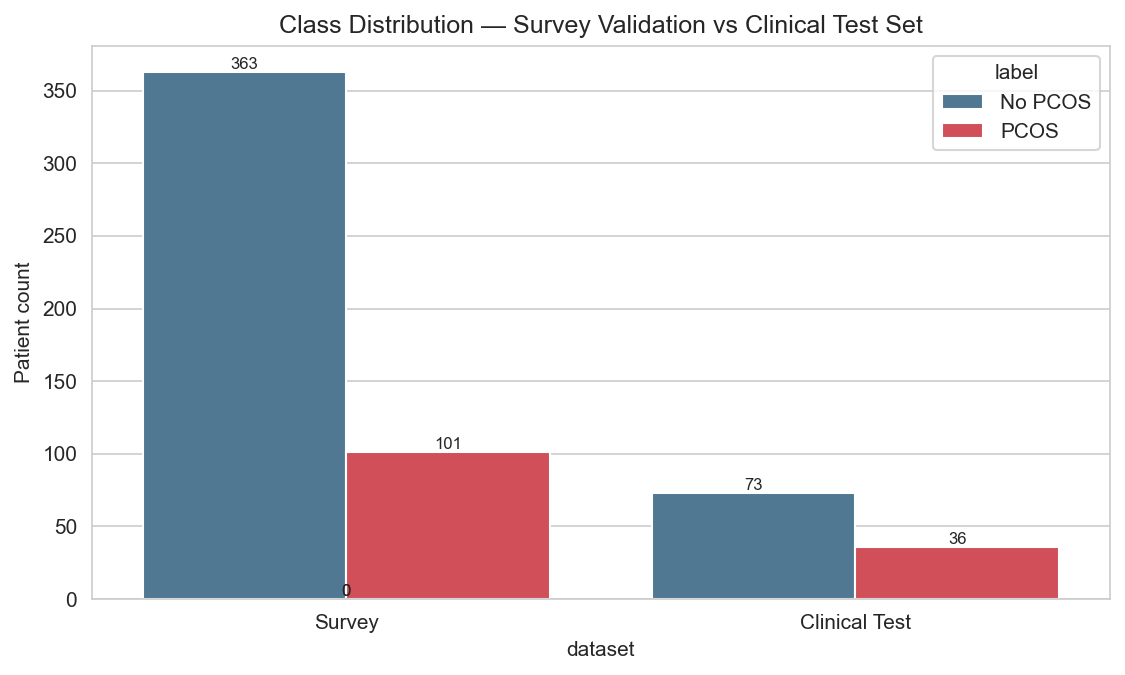

In [192]:
# Plotting the survey class-distribution comparison is showing how the survey set differs from the clinical test set.
fig, ax = plt.subplots(figsize=(7.6, 4.6))
sns.barplot(data=survey_balance_df, x='dataset', y='count', hue='label', palette=[COLORS['pcos_neg'], COLORS['pcos_pos']], ax=ax)
ax.set_title('Class Distribution — Survey Validation vs Clinical Test Set')
ax.set_ylabel('Patient count')
for patch in ax.patches:
    ax.annotate(f"{int(patch.get_height())}", (patch.get_x() + patch.get_width()/2, patch.get_height()), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'survey' / '25_survey_class_distribution.png', bbox_inches='tight')
plt.show()


### Survey Class Balance Insight

This chart is showing whether the survey label mix looks similar to the clinical test set or more imbalanced. This matters because a very different class mix can change how easy or hard it is for the model to hold its performance outside the clinical setting.


In [193]:
# Running the final non-invasive optimized stack on the survey data is testing external-style generalisation.
survey_meta_features, y_survey_proba = stack_predict_proba(final_bundle_m1, X_survey)
survey_threshold = float(final_bundle_m1.get('threshold', 0.5))
y_survey_pred = (y_survey_proba >= survey_threshold).astype(int)
survey_results = evaluate_prediction('Survey External Validation', y_survey, y_survey_pred, y_survey_proba)
print('Survey external validation results:')
for key, value in survey_results.items():
    if key == 'model':
        continue
    print(f'  {key:10s}: {value:.4f}')


Survey external validation results:
  accuracy  : 0.7134
  precision : 0.3841
  recall    : 0.5248
  f1        : 0.4435
  auc       : 0.6819


In [194]:
# Saving the survey validation outputs is preserving the external-style metrics and row-level predictions for later review.
pd.DataFrame([{
    'dataset': 'Survey External Validation',
    'n_patients': len(y_survey),
    **{k: v for k, v in survey_results.items() if k != 'model'}
}]).to_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'survey_validation_results.csv', index=False)

survey_prediction_df = pd.DataFrame(X_survey, columns=MODEL1_FEATURES)
survey_prediction_df['true_label'] = y_survey
survey_prediction_df['predicted_label'] = y_survey_pred
survey_prediction_df['predicted_proba'] = y_survey_proba
survey_prediction_df.to_csv(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'survey_validation_predictions.csv', index=False)
print('survey_validation_results.csv saved.')
print('survey_validation_predictions.csv saved.')


survey_validation_results.csv saved.
survey_validation_predictions.csv saved.


In [195]:
# Printing the ROC comparison table is preparing the exact values used in the survey ROC plot.
roc_compare_df = pd.DataFrame([
    {'dataset': 'Clinical Test', 'auc': roc_auc_score(y1_test, y_m1_proba)},
    {'dataset': 'Survey Validation', 'auc': roc_auc_score(y_survey, y_survey_proba)},
])
print(roc_compare_df.round(4).to_string(index=False))


          dataset    auc
    Clinical Test 0.9132
Survey Validation 0.6819


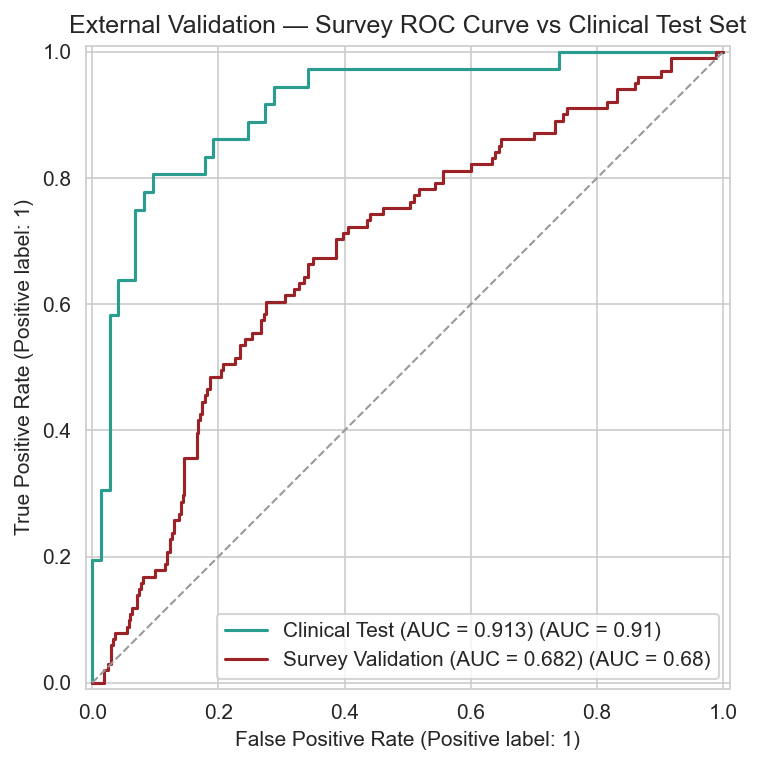

In [196]:
# Plotting the survey ROC curve against the clinical test ROC is showing how much discrimination holds outside the training context.
fig, ax = plt.subplots(figsize=(7.2, 5.2))
RocCurveDisplay.from_predictions(y1_test, y_m1_proba, ax=ax, name=f'Clinical Test (AUC = {roc_auc_score(y1_test, y_m1_proba):.3f})', color=COLORS['model1'])
RocCurveDisplay.from_predictions(y_survey, y_survey_proba, ax=ax, name=f'Survey Validation (AUC = {roc_auc_score(y_survey, y_survey_proba):.3f})', color=COLORS['survey'])
ax.plot([0, 1], [0, 1], linestyle='--', color='#999999', linewidth=1)
ax.set_title('External Validation — Survey ROC Curve vs Clinical Test Set')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'survey' / '26_survey_roc_curve.png', bbox_inches='tight')
plt.show()


### Survey ROC Insight

This ROC chart is showing how well the final non-invasive model separates positive and negative cases on survey data compared with the clinical test data. If the survey curve stays reasonably close to the clinical curve, that suggests the learned pattern is travelling outside the original clinical setting.


In [197]:
# Printing the survey confusion table is showing the exact classification outcomes before plotting.
cm_survey = confusion_matrix(y_survey, y_survey_pred)
cm_survey_df = pd.DataFrame(
    cm_survey,
    index=['Actual: No PCOS', 'Actual: PCOS'],
    columns=['Predicted: No PCOS', 'Predicted: PCOS'],
)
print(cm_survey_df.to_string())
print()
print(f"True Positives  : {cm_survey[1, 1]}")
print(f"False Negatives : {cm_survey[1, 0]}")
print(f"False Positives : {cm_survey[0, 1]}")
print(f"True Negatives  : {cm_survey[0, 0]}")


                 Predicted: No PCOS  Predicted: PCOS
Actual: No PCOS                 278               85
Actual: PCOS                     48               53

True Positives  : 53
False Negatives : 48
False Positives : 85
True Negatives  : 278


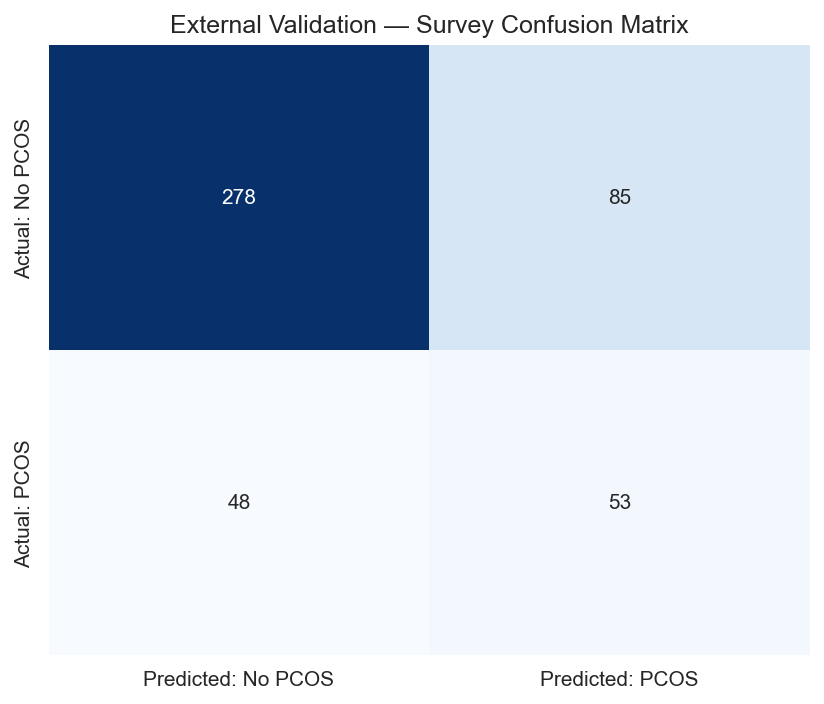

In [198]:
# Plotting the survey confusion matrix is showing what kinds of survey cases were caught and missed.
fig, ax = plt.subplots(figsize=(5.6, 4.8))
sns.heatmap(cm_survey_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
ax.set_title('External Validation — Survey Confusion Matrix')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'survey' / '27_survey_confusion_matrix.png', bbox_inches='tight')
plt.show()


### Survey Confusion Matrix Insight

This confusion matrix is showing how many survey cases were correctly flagged, missed, or wrongly flagged. The false negatives are especially important because they show the survey cases the model is not catching.


In [199]:
# Computing survey SHAP values with the saved Model 1 RF explainer is showing what the survey predictions are leaning on.
shap_values_survey_raw = explainer_m1.shap_values(X_survey)
sv_survey = extract_positive_shap(shap_values_survey_raw)
np.save(PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_values_survey.npy', sv_survey)
print('Survey SHAP matrix shape:')
print(sv_survey.shape)


Survey SHAP matrix shape:
(464, 19)


In [200]:
# Printing the survey SHAP ranking table is preparing the exact data behind the survey SHAP plots.
mean_abs_shap_survey = np.abs(sv_survey).mean(axis=0)
shap_rank_survey = pd.DataFrame({
    'feature': MODEL1_FEATURES,
    'mean_abs_shap': mean_abs_shap_survey,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
print('Survey SHAP ranking:')
print(shap_rank_survey.to_string(index=False))
print()
print('Clinical Model 1 SHAP ranking:')
print(shap_rank_m1[['feature', 'mean_abs_shap']].to_string(index=False))


Survey SHAP ranking:
                feature  mean_abs_shap
         symptom_burden       0.141643
        weight_gain_y_n       0.050382
      cycle_length_days       0.049287
     skin_darkening_y_n       0.049043
        hair_growth_y_n       0.048435
cycle_regularity_binary       0.044331
                age_yrs       0.043801
          fast_food_y_n       0.041779
            pimples_y_n       0.025508
         lifestyle_risk       0.015114
   regular_exercise_y_n       0.014881
              rbs_mg_dl       0.011340
                    bmi       0.011033
           bmi_category       0.010223
       bp_elevated_flag       0.009531
      diastolic_bp_mmhg       0.008428
        waist_hip_ratio       0.007123
          hair_loss_y_n       0.005040
       systolic_bp_mmhg       0.004517

Clinical Model 1 SHAP ranking:
                feature  mean_abs_shap
         symptom_burden       0.127385
      cycle_length_days       0.056898
        weight_gain_y_n       0.055814
     skin_d

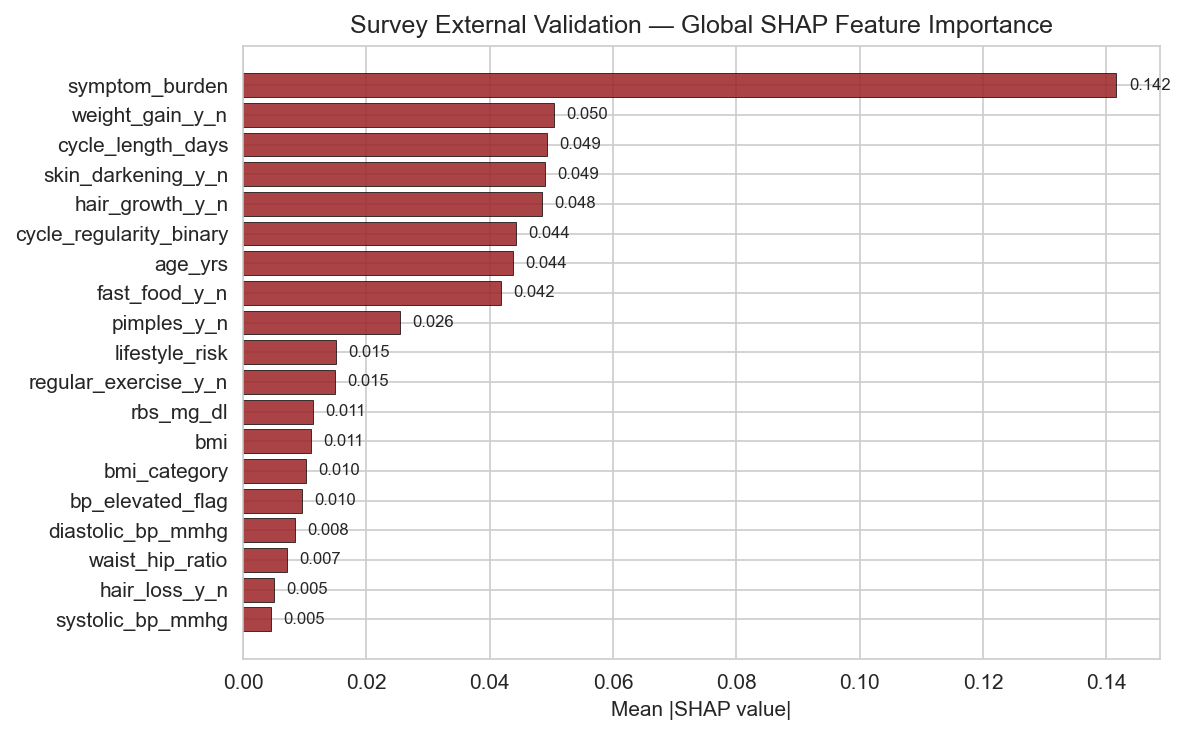

In [201]:
# Plotting the survey SHAP global bar chart is showing which features matter most in the external-style survey setting.
fig, ax = plt.subplots(figsize=(8.0, 5.0))
plot_survey_rank = shap_rank_survey.sort_values('mean_abs_shap', ascending=True)
bars = ax.barh(plot_survey_rank['feature'], plot_survey_rank['mean_abs_shap'], color=COLORS['survey'], alpha=0.85, edgecolor='black', linewidth=0.4)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Survey External Validation — Global SHAP Feature Importance')
for bar, value in zip(bars, plot_survey_rank['mean_abs_shap']):
    ax.text(value + 0.002, bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'survey' / '28_survey_shap_bar_global.png', bbox_inches='tight')
plt.show()


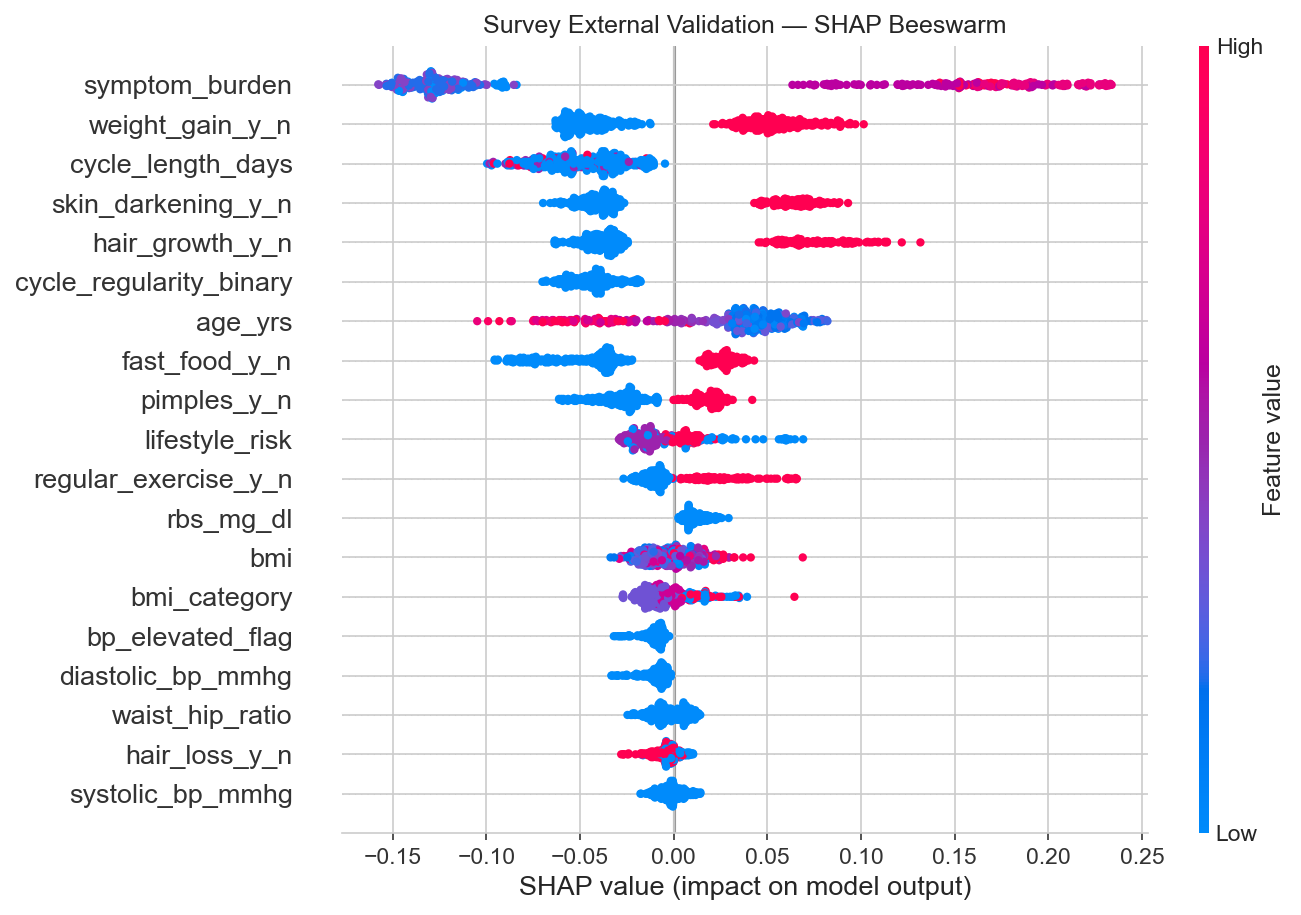

In [202]:
# Plotting the survey SHAP beeswarm is showing the direction and spread of the survey explanations patient by patient.
survey_df_features = pd.DataFrame(X_survey, columns=MODEL1_FEATURES)
shap.summary_plot(sv_survey, survey_df_features, feature_names=MODEL1_FEATURES, show=False, plot_size=(9.2, 6.2))
plt.title('Survey External Validation — SHAP Beeswarm')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'images' / 'shap' / 'survey' / '29_survey_shap_beeswarm.png', bbox_inches='tight')
plt.show()


### Survey SHAP Insight

These survey SHAP plots are showing whether the same non-invasive features are still dominating outside the clinical test setting. If the important features stay similar, that supports the idea that the model has learned a real non-invasive PCOS pattern rather than something highly specific to the training cohort.


In [203]:
# Writing the survey interpretation is summarizing how the external-style validation compared with the clinical test results.
clinical_m1_test = results_m1_final
top_overlap_survey = sorted(set(shap_rank_survey.head(5)['feature']) & set(shap_rank_m1.head(5)['feature']))
overlap_text = ', '.join([f'`{name}`' for name in top_overlap_survey]) if top_overlap_survey else 'limited on this run'
survey_markdown = (
    '### Survey Validation Interpretation\n'
    f'**What the result is showing:** The survey validation AUC is `{survey_results["auc"]:.3f}` and the recall is `{survey_results["recall"]:.3f}`, compared with the clinical test AUC of `{clinical_m1_test["auc"]:.3f}` and recall of `{clinical_m1_test["recall"]:.3f}`.\n\n'
    '**What this means:** This shows whether the non-invasive signal learned from the clinical cohort is still visible in the self-reported survey setting.\n\n'
    '**Why this matters:** The survey set is more like a real-world screening situation, but it is also noisier and partly placeholder-filled.\n\n'
    f'**Simple summary:** The survey validation gives an external-style check, not a perfect external clinical validation. The top-five SHAP overlap is {overlap_text}.'
)
render_markdown(survey_markdown)


### Survey Validation Interpretation
**What the result is showing:** The survey validation AUC is `0.682` and the recall is `0.525`, compared with the clinical test AUC of `0.913` and recall of `0.722`.

**What this means:** This shows whether the non-invasive signal learned from the clinical cohort is still visible in the self-reported survey setting.

**Why this matters:** The survey set is more like a real-world screening situation, but it is also noisier and partly placeholder-filled.

**Simple summary:** The survey validation gives an external-style check, not a perfect external clinical validation. The top-five SHAP overlap is `cycle_length_days`, `skin_darkening_y_n`, `symptom_burden`, `weight_gain_y_n`.

## Section 6 — Final Verification


In [204]:
# Checking every required output file is confirming that the full Notebook 11 output contract was completed.
required_files = [
    PROJECT_ROOT / 'images' / 'shap' / '01_shap_concept_diagram.png',
    PROJECT_ROOT / 'images' / 'shap' / '02_shap_game_theory_illustration.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '03_m1_shap_bar_global.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '04_m1_shap_beeswarm.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '05_m1_shap_heatmap.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '06_m1_shap_waterfall_true_positive.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '07_m1_shap_waterfall_false_negative.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '08_m1_shap_waterfall_false_positive.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '09_m1_shap_dependence_feature1.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '10_m1_shap_dependence_feature2.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '11_m1_shap_dependence_feature3.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '12_m1_shap_interaction_bmi_cycle.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model1' / '13_m1_meta_base_learner_weights.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '14_m2_shap_bar_global.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '15_m2_shap_beeswarm.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '16_m2_shap_heatmap.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '17_m2_shap_waterfall_true_positive.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '18_m2_shap_waterfall_false_negative.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '19_m2_shap_waterfall_false_positive.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '20_m2_shap_dependence_feature1.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '21_m2_shap_dependence_feature2.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '22_m2_shap_dependence_feature3.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '23_m2_shap_interaction_amh_fsh.png',
    PROJECT_ROOT / 'images' / 'shap' / 'model2' / '24_m2_meta_base_learner_weights.png',
    PROJECT_ROOT / 'images' / 'shap' / 'survey' / '25_survey_class_distribution.png',
    PROJECT_ROOT / 'images' / 'shap' / 'survey' / '26_survey_roc_curve.png',
    PROJECT_ROOT / 'images' / 'shap' / 'survey' / '27_survey_confusion_matrix.png',
    PROJECT_ROOT / 'images' / 'shap' / 'survey' / '28_survey_shap_bar_global.png',
    PROJECT_ROOT / 'images' / 'shap' / 'survey' / '29_survey_shap_beeswarm.png',
    PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_values_model1.npy',
    PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_values_model2.npy',
    PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_values_survey.npy',
    PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_feature_ranking_model1.csv',
    PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'shap_feature_ranking_model2.csv',
    PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'survey_validation_results.csv',
    PROJECT_ROOT / 'cleaned_data' / 'modelling_sets' / 'survey_validation_predictions.csv',
]

all_passed = True
for path in required_files:
    exists = path.exists()
    non_empty = exists and path.stat().st_size > 0
    status = 'PASS' if (exists and non_empty) else 'FAIL'
    if status == 'FAIL':
        all_passed = False
    print(f'[{status}] {path}')

print()
if all_passed:
    print('All Notebook 11 outputs exist and are non-empty.')
else:
    print('Some Notebook 11 outputs are missing or empty.')


[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\shap\01_shap_concept_diagram.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\shap\02_shap_game_theory_illustration.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\shap\model1\03_m1_shap_bar_global.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\shap\model1\04_m1_shap_beeswarm.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\shap\model1\05_m1_shap_heatmap.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\shap\model1\06_m1_shap_waterfall_true_positive.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\shap\model1\07_m1_shap_waterfall_false_negative.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\images\shap\model1\08_m1_shap_waterfall_false_positive.png
[PASS] C:\Users\USER\Documents\GitHub\pcos-predictor-metaheuristic\im

## Notebook Summary and Next Steps

This notebook is teaching SHAP, explaining the final optimized non-invasive model, explaining the final optimized invasive model, and testing the non-invasive model on the survey external validation set. The Model 1 SHAP results are showing which routine features are driving the final screening model. The Model 2 SHAP results are showing which hormonal and ultrasound features are driving the invasive benchmark. The survey section is showing how well the non-invasive model travels outside the clinical test setting.

Notebook 12 will be building the final Streamlit application. It will expose both optimized models, the SHAP explanation views, patient input forms, model performance pages, and the study-level insights in a single interactive interface.
